# Ejercicio Feedback Matemáticas y Estadística 1

Este dataset contiene información sobre más de 47,000 partidos internacionales de fútbol
masculino, desde el primer partido oficial en 1872 hasta la actualidad, incluyendo datos de
torneos históricos como la Copa Mundial de la FIFA y partidos amistosos.
Tu tarea es analizar este conjunto de datos utilizando las técnicas y herramientas aprendidas a
lo largo del curso: estadística descriptiva, análisis EDA, modelos de clasificación y decisión,
estimación bayesiana, depuración e imputación de datos, y redes neuronales avanzadas.
Además, deberás responder preguntas clave sobre el impacto de jugar en casa, tendencias
históricas, y los factores que influyen en los resultados.
Este análisis se realizará de manera individual y se entregará como un informe final.

**Contexto del Dataset**

El archivo principal, results.csv, incluye las siguientes columnas:
* date: Fecha del partido.
* home_team y away_team: Equipos locales y visitantes, respectivamente.
* home_score y away_score: Resultados finales, incluyendo tiempo extra (sin penales).
* tournament: Nombre del torneo.
* city y country: Ubicación del partido.
* neutral: Indica si el partido se jugó en un campo neutral (TRUE/FALSE).
Este dataset está diseñado para responder preguntas como:
* ¿Qué equipos dominan históricamente en casa y en torneos específicos?
* ¿Cómo han evolucionado las tendencias de goles anotados a lo largo de la historia?
* ¿Existe una ventaja clara al jugar como local?
* ¿Qué insights pueden extraerse mediante el uso de grafos o redes neuronales?
Tu análisis debe abordar estas preguntas e incluir visualizaciones y modelos predictivos
basados en los datos.

In [ ]:
#IMportamos nuestras librerías de confianza
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [ ]:
#Leemos nuestros datos

Results=pd.read_csv('results.csv')


---
---

#***Exploración Inicial y Análisis descriptivo***

## **Exploración Inicial, EDA y Limpieza de Datos (1 puntos)**

### Carga y explora el archivo results.csv

#### Identifica las variables disponibles, tipos de datos y posibles errores (valores nulos, nombres duplicados).

In [ ]:
Results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [ ]:
Results.dtypes

,0
date,object
home_team,object
away_team,object
home_score,int64
away_score,int64
tournament,object
city,object
country,object
neutral,bool


In [ ]:
Results.isnull().sum()

,0
date,0
home_team,0
away_team,0
home_score,0
away_score,0
tournament,0
city,0
country,0
neutral,0


In [ ]:
Results.isna().sum()

,0
date,0
home_team,0
away_team,0
home_score,0
away_score,0
tournament,0
city,0
country,0
neutral,0


In [ ]:
Duplicados=Results.duplicated()
Duplicados.sum()

0

#### Realiza una limpieza básica de los datos, incluyendo corrección de inconsistencias.

In [ ]:
#Como ya hemos visto no hay nulos ni duplicados
# Ejemplo: estandarizar nombres de torneos elimino espacios
   # o
Results['tournament'] = Results['tournament'].str.strip() # Eliminamos espacios en blanco al inicio y al final
   # o
Results['country'] = Results['country'].str.title() # Estandarizamos el nombre de los países
Results['city'] = Results['city'].str.title() # Estandarizamos el nombre de las ciudades
Results['home_team']= Results['home_team'].str.title() # Estandarizamos el nombre de los equipos locales
Results['away_team']= Results['away_team'].str.title() # Estandarizamos el nombre de los equipos visitantes
   #0
Results['date'] = pd.to_datetime(Results['date']) # Convertimos la columna 'date' a tipo datetime

In [ ]:
#Vemos como queda
Results.head(20)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False
5,1876-03-25,Scotland,Wales,4,0,Friendly,Glasgow,Scotland,False
6,1877-03-03,England,Scotland,1,3,Friendly,London,England,False
7,1877-03-05,Wales,Scotland,0,2,Friendly,Wrexham,Wales,False
8,1878-03-02,Scotland,England,7,2,Friendly,Glasgow,Scotland,False
9,1878-03-23,Scotland,Wales,9,0,Friendly,Glasgow,Scotland,False


In [ ]:
Results['tournament'].unique()

array(['Friendly', 'British Home Championship', 'Évence Coppée Trophy',
       'Muratti Vase', 'Copa Lipton', 'Copa Newton',
       'Copa Premio Honor Argentino', 'Copa Premio Honor Uruguayo',
       'Far Eastern Championship Games', 'Copa Roca', 'Copa América',
       'Peace Cup', 'Open International Championship',
       'Copa Chevallier Boutell', 'Olympic Games', 'Nordic Championship',
       'Central European International Cup', 'Baltic Cup', 'Balkan Cup',
       'Central American and Caribbean Games', 'FIFA World Cup',
       'Copa Rio Branco', 'FIFA World Cup qualification',
       'Bolivarian Games', 'CCCF Championship', 'NAFC Championship',
       'Copa Oswaldo Cruz', 'Asian Games', 'Pan American Championship',
       'Copa del Pacífico', "Copa Bernardo O'Higgins",
       'AFC Asian Cup qualification', 'Atlantic Cup', 'AFC Asian Cup',
       'African Cup of Nations', 'Copa Paz del Chaco',
       'Merdeka Tournament', 'UEFA Euro qualification',
       'Southeast Asian Peninsular

#### Implementa métodos de imputación para manejar datos faltantes.


*   Variables categóricas: imputación por moda.
*   Variables númericas: media, mediana o interpolación.



In [ ]:
#Nuestro dataframe no posee datos faltantes,en caso de haberlas habido se hubiera podido paliar con la moda en el caso categórico
df['columna'] = df['columna'].fillna(df['columna'].mode()[0])
#O por interpolación en el caso contínuo
df['columna'] = df['columna'].interpolate(method='linear') #Interpolación lineal

NameError: name 'df' is not defined

### Exploración Inicial EDA

#### Identifica distribuciones principales (histogramas, boxplots, etc).

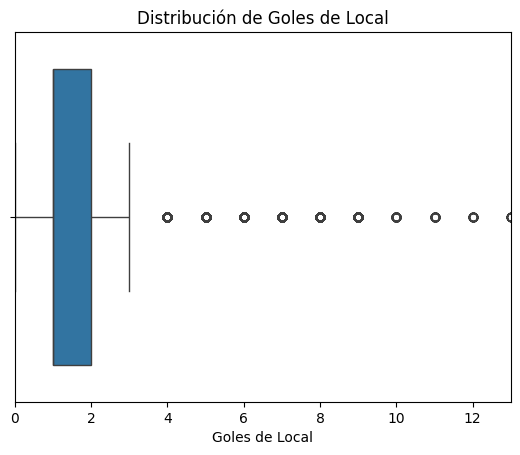

In [ ]:
#Mi única variable numérica son los goles en casa y fuera de casa, hago un box plot con esas dos
import seaborn as sns
import matplotlib.pyplot as plt

# Asumiendo que 'Results' es tu DataFrame
sns.boxplot(x='home_score', data=Results)
plt.title('Distribución de Goles de Local') # Añadir un título
plt.xlabel('Goles de Local') # Añadir etiqueta al eje x
plt.xlim(0, 13) # Establecer el rango del eje x
plt.show()

Vemos que la mayoría de datos se encuentran entre uno y dos goles, pudiendose ver casos de hasta 3 goles en un rango típico.
Se pueden ver tambien outliers de muchos más goles incluso 13.

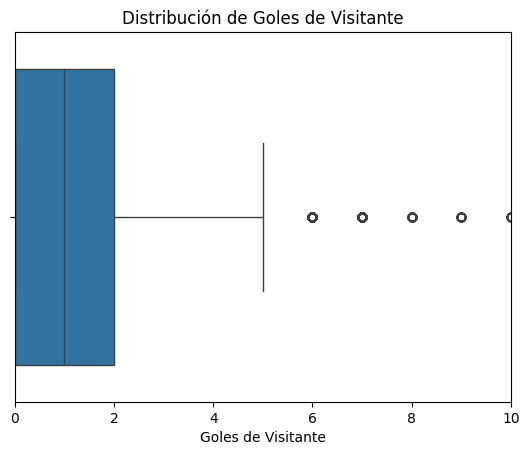

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='away_score', data=Results)  # 'away_score'
plt.title('Distribución de Goles de Visitante')
plt.xlabel('Goles de Visitante')

# Acotar el eje x
plt.xlim(0, 10)  # Mostrar valores entre 0 y 10

plt.show()

Tenemos un análisi parecido al home score pero esta vez la mayoría de los datos se centran entre 0 y 2 goles, con valores típicos de hasta 5 goles. Además tambien se ven los outliers como en el caso anterior.

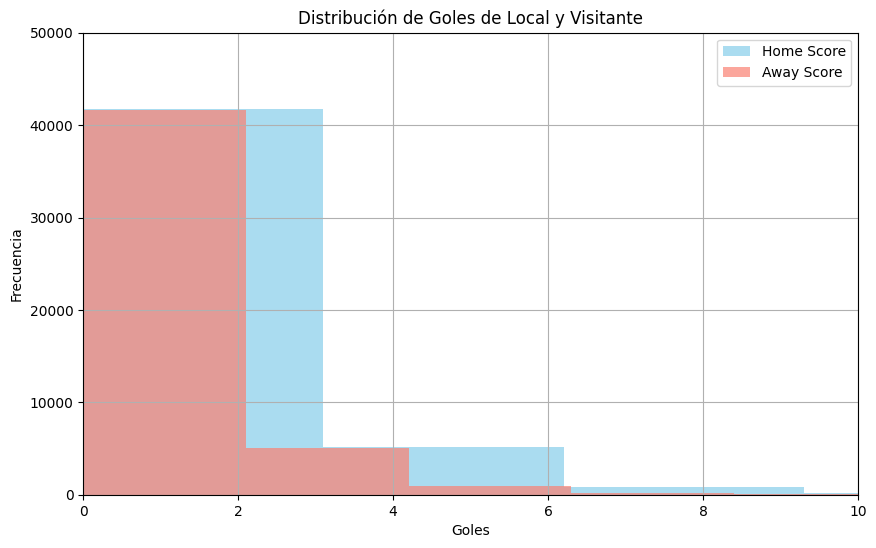

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #opcional, para un estilo más atractivo

# Suponiendo que tu DataFrame se llama 'Results'
plt.figure(figsize=(10, 6)) # Ajusta el tamaño de la figura si es necesario

# Histograma para 'home_score'
plt.hist(Results['home_score'], bins=10, alpha=0.7, label='Home Score', color='skyblue')
# bins controla el número de barras, alpha la transparencia

# Histograma para 'away_score'
plt.hist(Results['away_score'], bins=10, alpha=0.7, label='Away Score', color='salmon')

plt.title('Distribución de Goles de Local y Visitante')
plt.xlabel('Goles')
plt.xlim(0, 10) # Ajusta el rango del eje x si es necesario
plt.ylim(0,50000)
plt.ylabel('Frecuencia')
plt.legend() # Muestra la leyenda para identificar las series
plt.grid(True) # Añade una cuadrícula para facilitar la lectura

plt.show()

Respaldo el EDA con más visualizaciones como por ejemplo la frecuencia de los torneos

In [ ]:
#Los torneos con más partidos juugados
tournament_counts = Results['tournament'].value_counts()
tournament_counts.head(20)

,count
tournament,
Friendly,18040
FIFA World Cup qualification,8268
UEFA Euro qualification,2824
African Cup of Nations qualification,2218
FIFA World Cup,964
Copa América,873
African Cup of Nations,793
AFC Asian Cup qualification,770
UEFA Nations League,630


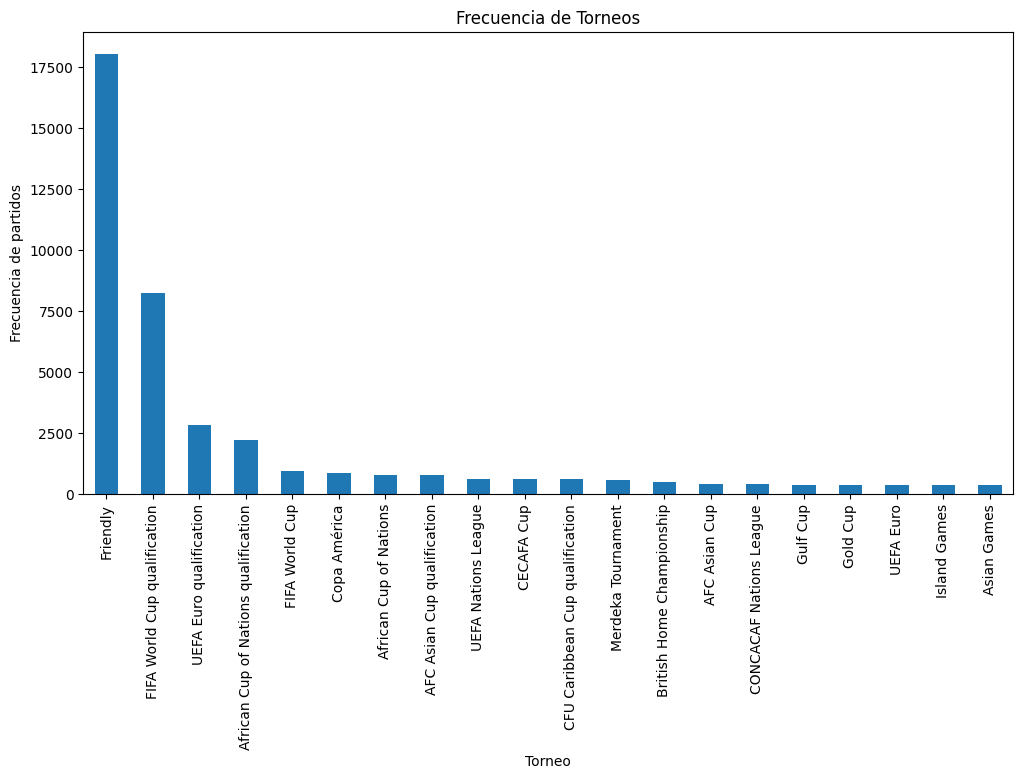

In [ ]:
# Gráfico de barras para la frecuencia de cada torneo

tournament_counts = Results['tournament'].value_counts().head(20)
plt.figure(figsize=(12, 6))  # Ajusta el tamaño si es necesario
tournament_counts.plot(kind='bar')
plt.title('Frecuencia de Torneos')
plt.xlabel('Torneo')
plt.ylabel('Frecuencia de partidos')
plt.xticks(rotation=90)  # Rota las etiquetas del eje x para mejor legibilidad
plt.show()

In [ ]:
#Los veinte que más veces han jugado en casa
home_team_counts = Results['home_team'].value_counts().head(20)
home_team_counts.head(20)

,count
home_team,
Brazil,605
Argentina,595
Mexico,584
Germany,545
South Korea,545
England,540
France,525
Sweden,524
Hungary,489


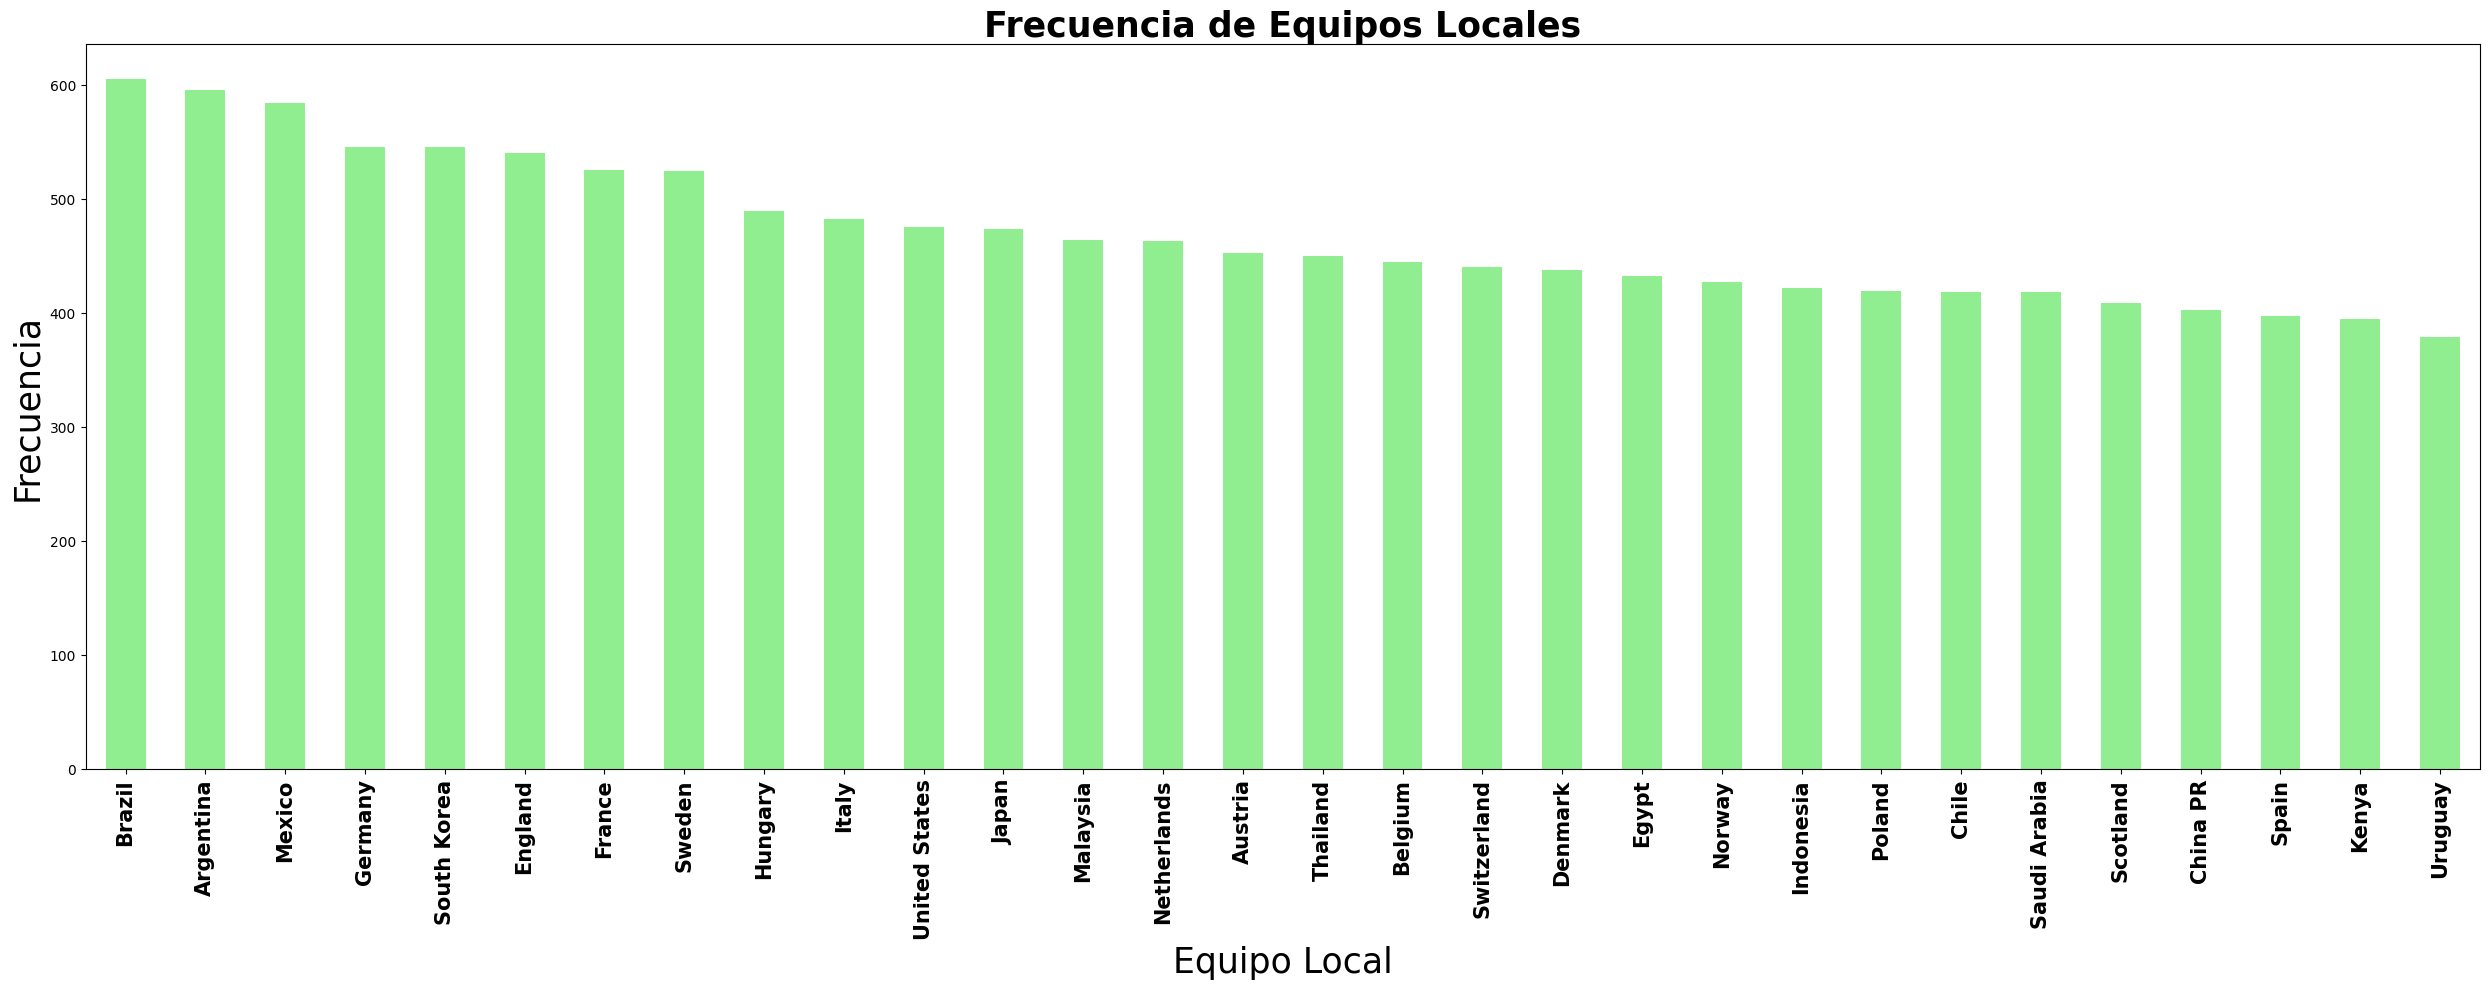

In [ ]:
#Home Team
import pandas as pd
import matplotlib.pyplot as plt

# Asumiendo que 'Results' es tu DataFrame
home_team_counts = Results['home_team'].value_counts().head(30)

plt.figure(figsize=(25, 10))  # Ajustar el tamaño de la figura si es necesario
home_team_counts.plot(kind='bar', color='lightgreen')
plt.title('Frecuencia de Equipos Locales',size=25, fontweight='bold')
plt.xlabel('Equipo Local', size=25)
plt.ylabel('Frecuencia', size=25)
plt.xticks(rotation=90 , size= 15, fontweight='bold')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.tight_layout()  # Ajustar el diseño para evitar que las etiquetas se superpongan
plt.show()

In [ ]:
#Los veinte equipos que más han jugado de Visitantes
away_team_counts = Results['away_team'].value_counts().head(20)
away_team_counts.head(20)

,count
away_team,
Uruguay,575
Sweden,557
England,536
Hungary,502
Paraguay,486
Germany,469
Argentina,458
Poland,458
Zambia,453


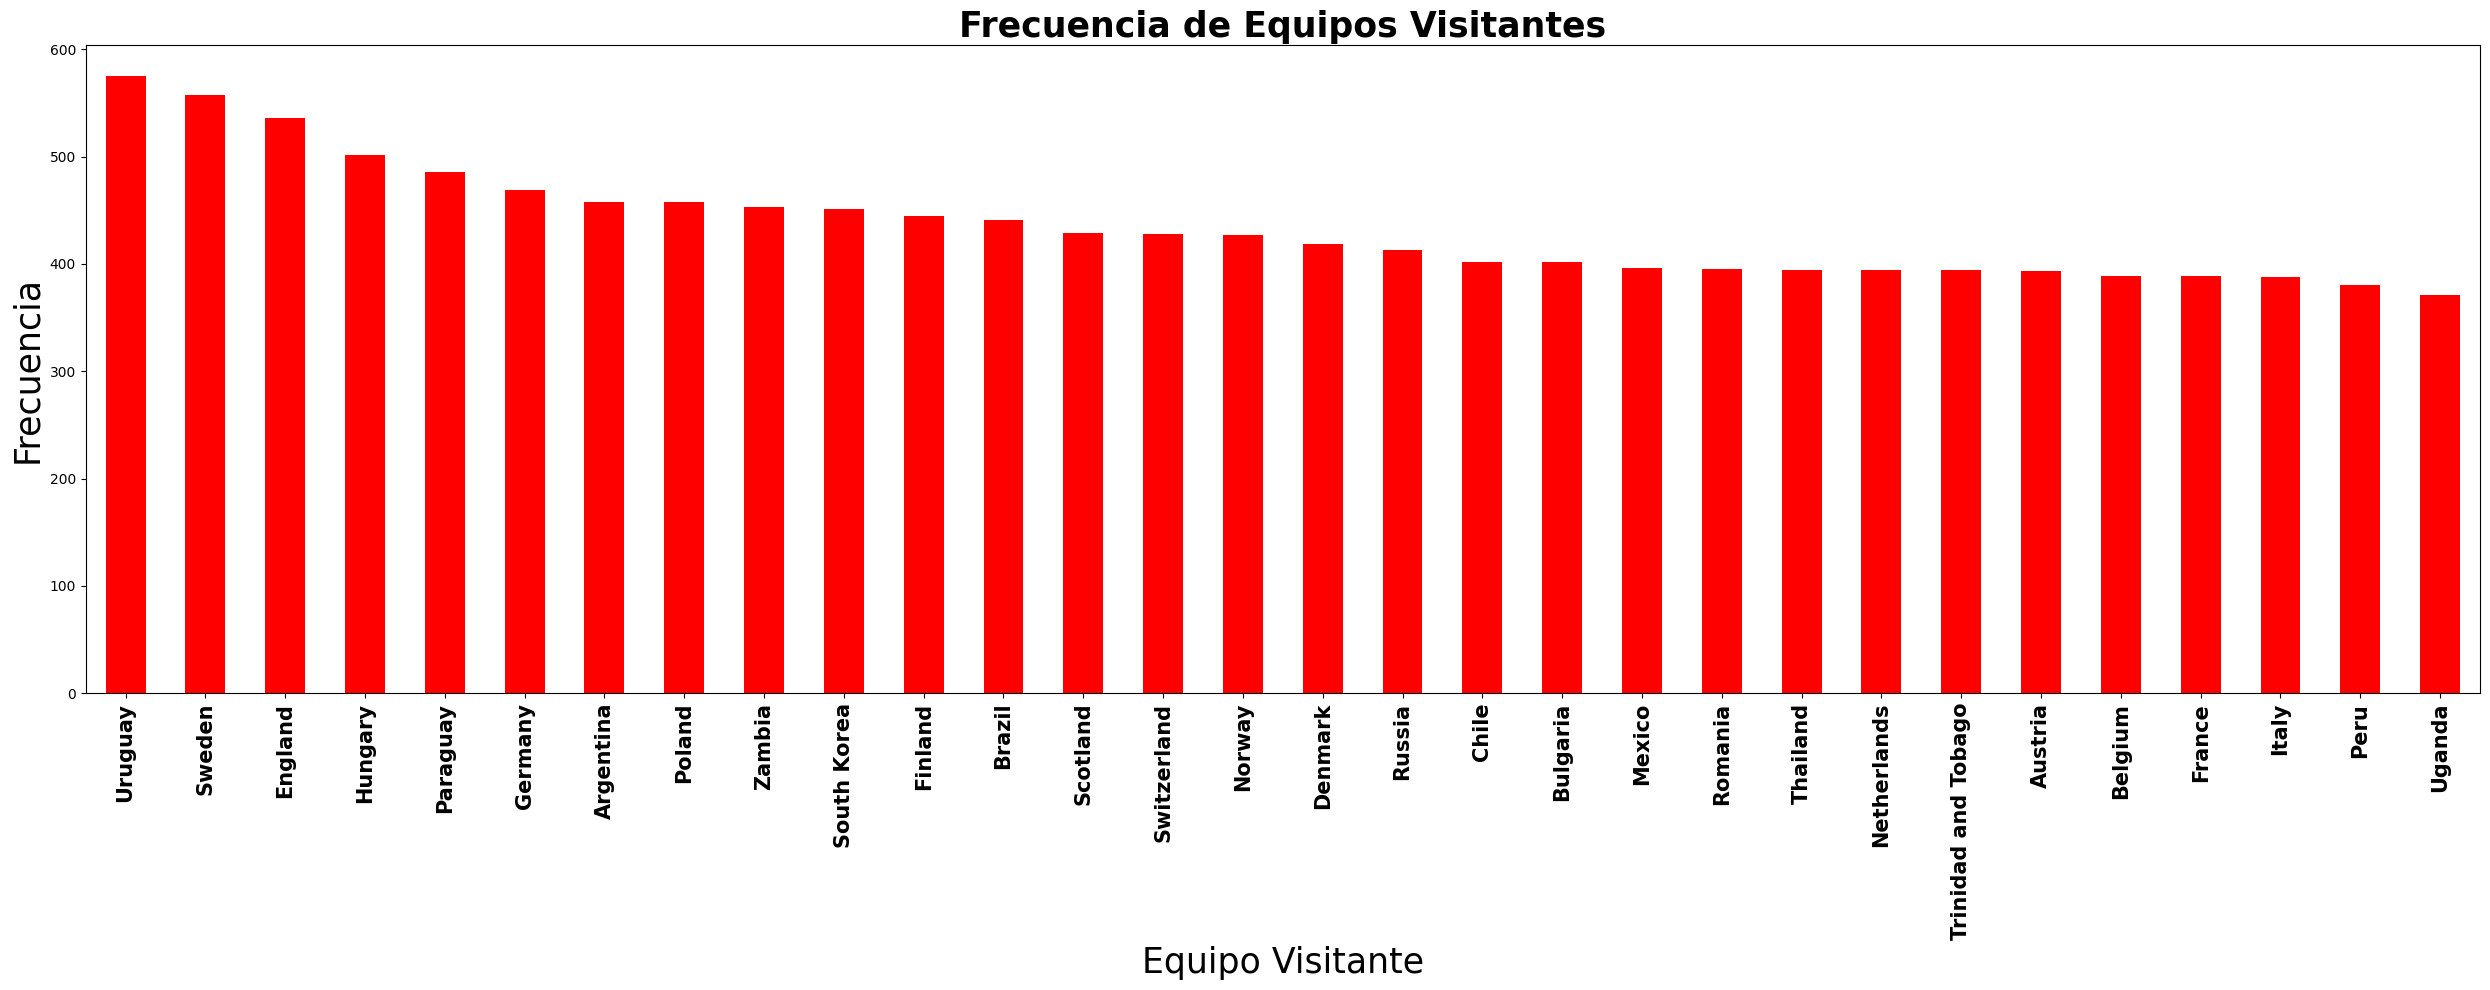

In [ ]:
#Away Team
import pandas as pd
import matplotlib.pyplot as plt

# Asumiendo que 'Results' es tu DataFrame
away_team_counts = Results['away_team'].value_counts().head(30)

plt.figure(figsize=(25, 10))  # Ajustar el tamaño de la figura si es necesario
away_team_counts.plot(kind='bar', color='red')
plt.title('Frecuencia de Equipos Visitantes',size=25, fontweight='bold')
plt.xlabel('Equipo Visitante', size=25)
plt.ylabel('Frecuencia', size=25)
plt.xticks(rotation=90 , size= 15, fontweight='bold')  # Rotar las etiquetas del eje x para mejor legibilidad
plt.tight_layout()  # Ajustar el diseño para evitar que las etiquetas se superpongan
plt.show()

**Ahora los histogramas de las demás variables categóricas**

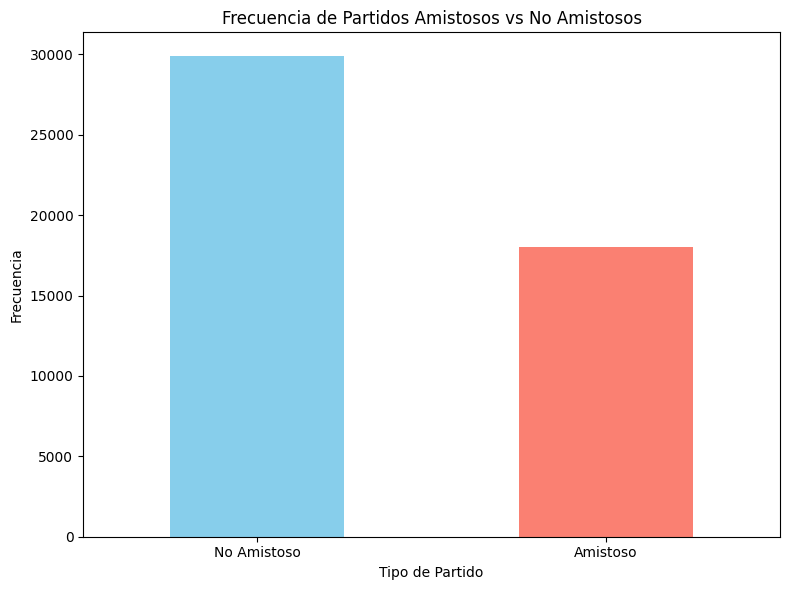

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Crear una nueva columna 'is_friendly'
Results['is_friendly'] = Results['tournament'].apply(lambda x: 'Amistoso' if x == 'Friendly' else 'No Amistoso')

# Contar la frecuencia de partidos amistosos y no amistosos
friendly_counts = Results['is_friendly'].value_counts()

# Crear el histograma
plt.figure(figsize=(8, 6))
friendly_counts.plot(kind='bar', color=['skyblue', 'salmon'])  # Asignar colores a las barras
plt.title('Frecuencia de Partidos Amistosos vs No Amistosos')
plt.xlabel('Tipo de Partido')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)  # No rotar las etiquetas del eje x en este caso
plt.tight_layout()
plt.show()

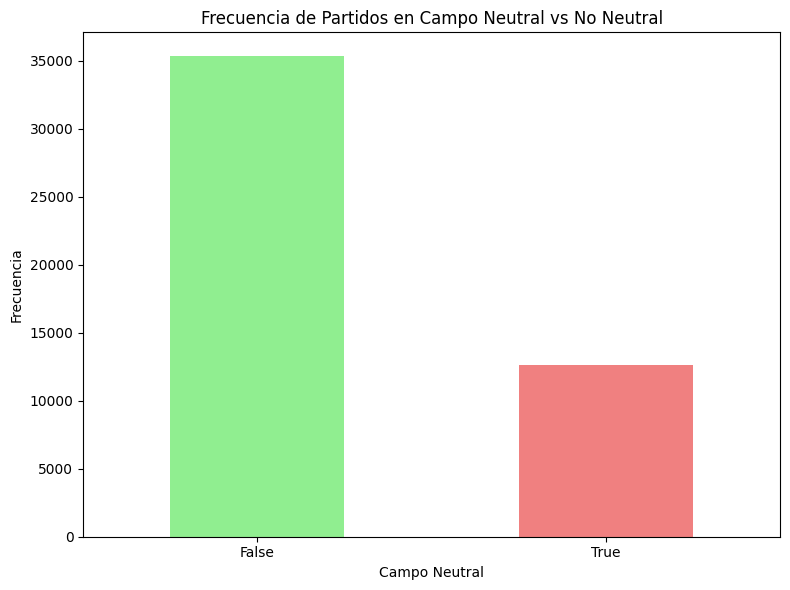

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Contar la frecuencia de partidos en campo neutral y no neutral
neutral_counts = Results['neutral'].value_counts()

# Crear el histograma
plt.figure(figsize=(8, 6))
neutral_counts.plot(kind='bar', color=['lightgreen', 'lightcoral'])  # Asignar colores a las barras
plt.title('Frecuencia de Partidos en Campo Neutral vs No Neutral')
plt.xlabel('Campo Neutral')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)  # No rotar las etiquetas del eje x en este caso
plt.tight_layout()
plt.show()

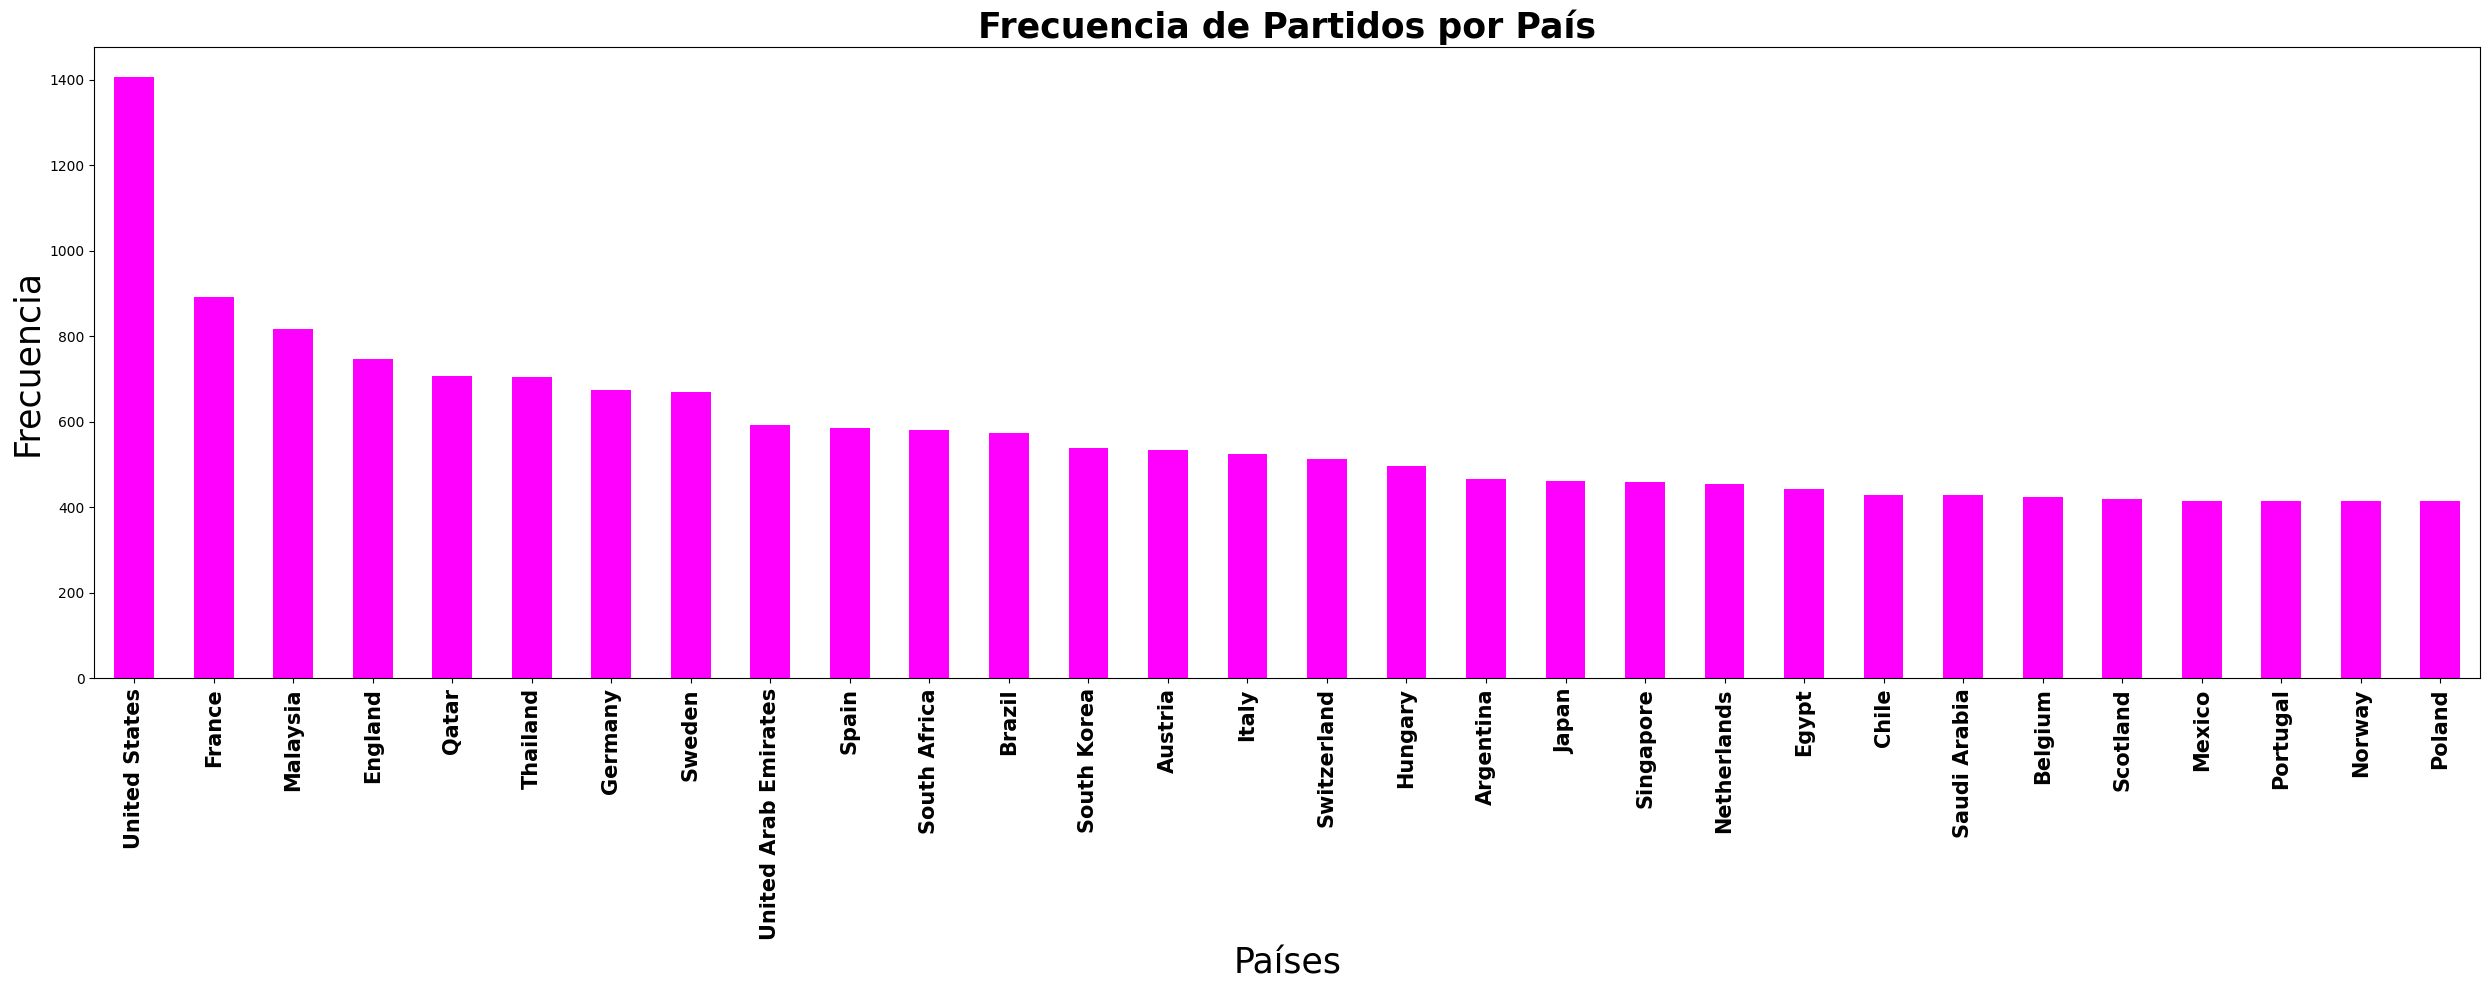

In [ ]:

# Histograma de Países con más partidos
country_counts = Results['country'].value_counts().head(30)

plt.figure(figsize=(25, 10))  # Ajustar el tamaño según la cantidad de países
country_counts.plot(kind='bar', color='magenta')
plt.title('Frecuencia de Partidos por País',size=25, fontweight='bold')
plt.xlabel('Países', size=25)
plt.ylabel('Frecuencia', size=25)
plt.xticks(rotation=90 , size= 15, fontweight='bold') # Rotar etiquetas del eje x para mejor legibilidad
plt.tight_layout()
plt.show()

In [ ]:
#Ciudades en las que más se ha jugado
city_counts = Results['city'].value_counts()
city_counts.head(20)

,count
city,
Kuala Lumpur,730
Bangkok,574
Doha,547
London,430
Budapest,429
Montevideo,369
Kuwait City,364
Vienna,358
Oslo,351


#### Analiza correlaciones iniciales entre variables cuantitativas (matriz de correlación).

In [ ]:
#Cambio Neutral por ceros y unos
Results['neutral'] = Results['neutral'].astype(int)

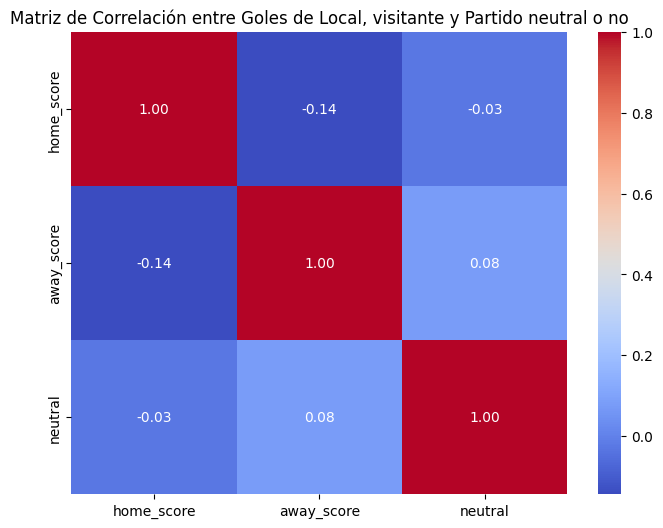

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcula la matriz de correlación
correlation_matrix = Results[['home_score', 'away_score','neutral']].corr()

# Crea un mapa de calor de la matriz de correlación
plt.figure(figsize=(8, 6))  # Ajusta el tamaño de la figura si es necesario
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación entre Goles de Local, visitante y Partido neutral o no')
plt.show()

Podemos ver que nuestras variables contínuas no tienen mucha relación entre sí, aunque si podemos valorar que cierta correlación negativa entre el resultado en casa y fuera de casa.

#### Si fuese necesario, crea variables derivadas, como, por ejemplo: diferencia de goles, década del partido, etc.


*  Analiza relaciones categóricas, como frecuencia de victorias
locales o torneos más populares, utilizando gráficos de barras
y/o mapas de calor.




In [ ]:
#Creo una nuevas variables, diferencia de goles y década de partido
Results['Goal_diff'] = Results['home_score'] - Results['away_score']
Results['Decade'] = (Results['date'].dt.year // 10) * 10
Results['Win']= np.where(Results['home_score'] > Results['away_score'], 1, 0)
Results.head(20)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,is_friendly,Goal_diff,Decade,Win
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,0,Amistoso,0,1870,0
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,0,Amistoso,2,1870,1
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,0,Amistoso,1,1870,1
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,0,Amistoso,0,1870,0
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,0,Amistoso,3,1870,1
5,1876-03-25,Scotland,Wales,4,0,Friendly,Glasgow,Scotland,0,Amistoso,4,1870,1
6,1877-03-03,England,Scotland,1,3,Friendly,London,England,0,Amistoso,-2,1870,0
7,1877-03-05,Wales,Scotland,0,2,Friendly,Wrexham,Wales,0,Amistoso,-2,1870,0
8,1878-03-02,Scotland,England,7,2,Friendly,Glasgow,Scotland,0,Amistoso,5,1870,1
9,1878-03-23,Scotland,Wales,9,0,Friendly,Glasgow,Scotland,0,Amistoso,9,1870,1


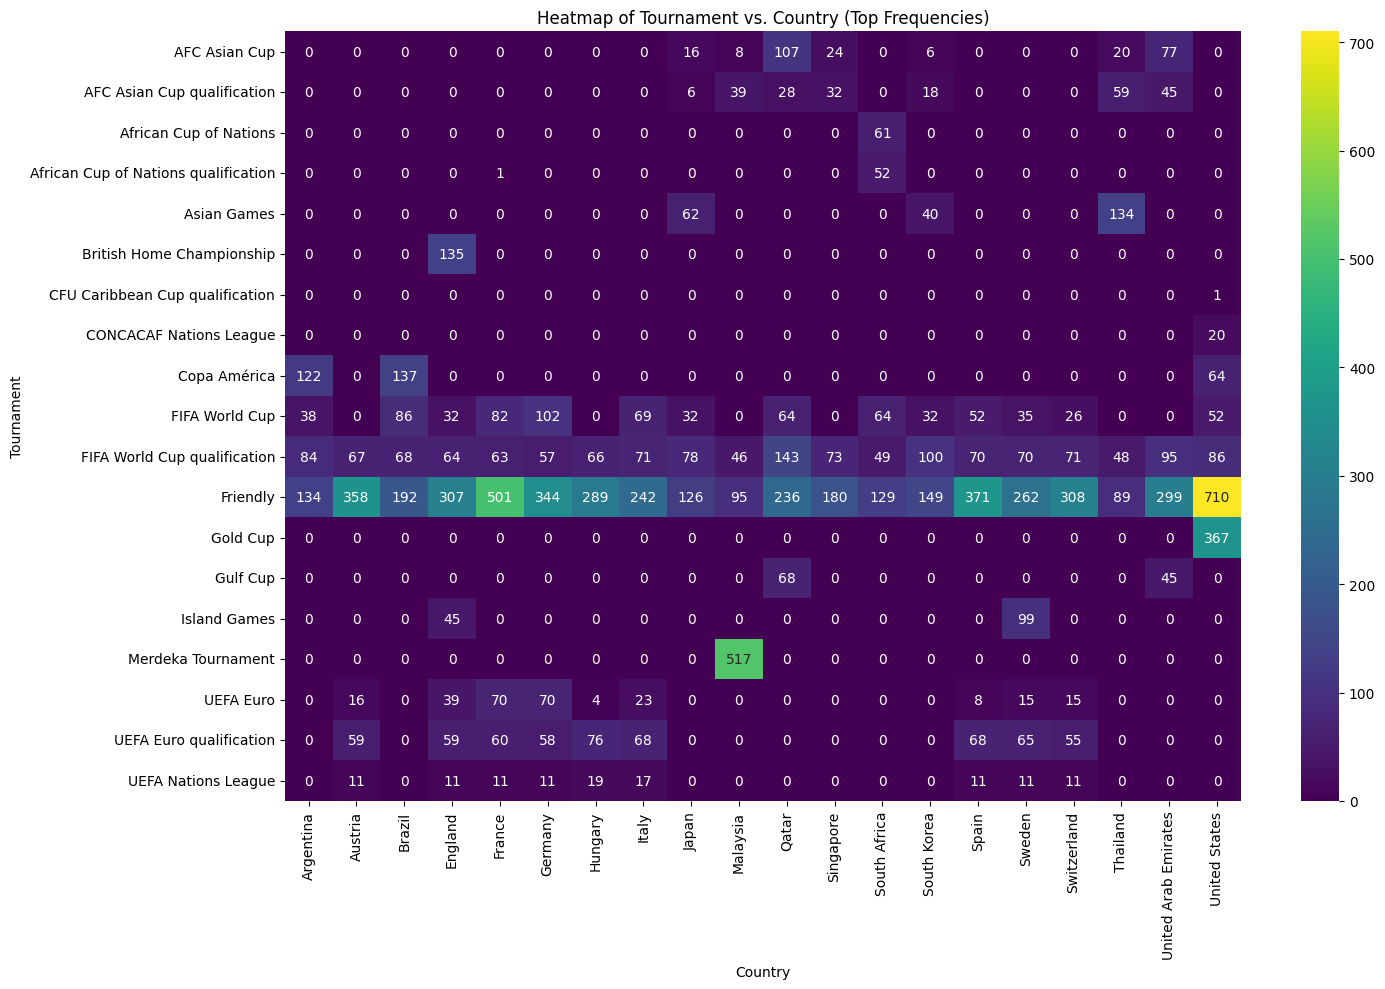

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the number of top tournaments and countries to include
top_n_tournaments = 20  # Example: Top 20 tournaments
top_n_countries = 20  # Example: Top 15 countries

# Get the most frequent tournaments and countries
top_tournaments = Results['tournament'].value_counts().head(top_n_tournaments).index
top_countries = Results['country'].value_counts().head(top_n_countries).index

# Filter the DataFrame to include only the selected tournaments and countries
filtered_results = Results[Results['tournament'].isin(top_tournaments) & Results['country'].isin(top_countries)]

# Create the contingency table
contingency_table = pd.crosstab(filtered_results['tournament'], filtered_results['country'])

# Create the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(contingency_table, annot=True, cmap='viridis', fmt="d")
plt.title('Heatmap of Tournament vs. Country (Top Frequencies)')
plt.xlabel('Country')
plt.ylabel('Tournament')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Analizando este mapa de calor podemos decir que uno de los troneos más populares han sido los friendly games llegando a jugar cerca de 700 partidos en estados unidos y tambien los clasificatorios de mundial, con muchos partidos repartidos entre los países.

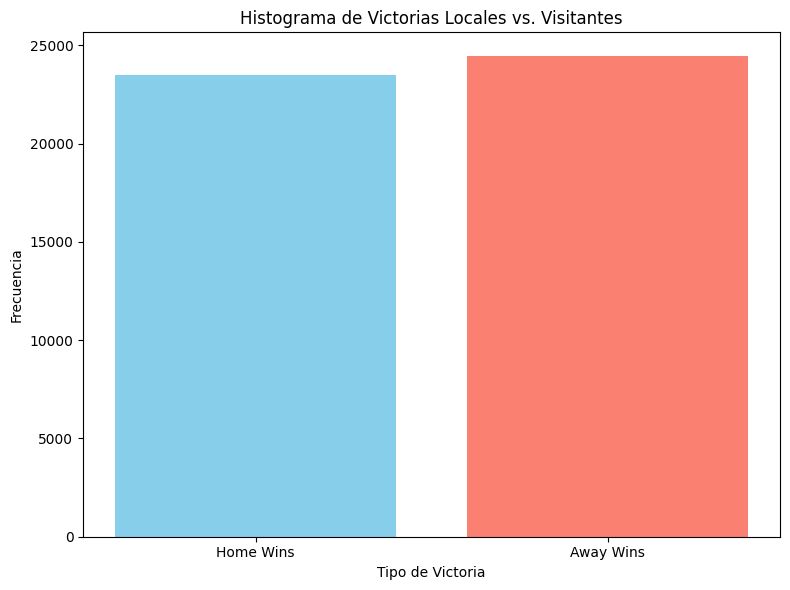

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Count home and away wins
home_wins = Results['Win'].sum()
away_wins = len(Results['Win']) - home_wins # or (Results['Win'] == 0).sum() for explicit away win count
# Create the histogram
plt.figure(figsize=(8, 6))
plt.bar(['Home Wins', 'Away Wins'], [home_wins, away_wins], color=['skyblue', 'salmon'])
plt.title('Histograma de Victorias Locales vs. Visitantes')
plt.xlabel('Tipo de Victoria')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

#### Entrega un informe en .pdf (máximo 2 páginas) con:



* Tablas descriptivas que incluyan estadísticas básicas (media,
medianrango, etc.).
* Ejemplos concretos de limpieza antes y después.
* Visualizaciones iniciales para respaldar el EDA.





In [ ]:
#Estadísticas Básic
Results.describe()


,date,home_score,away_score,neutral,Goal_diff,Decade,Win
count,47917,47917.000000,47917.000000,47917.000000,47917.000000,47917.000000,47917.000000
mean,1993-06-18 17:52:02.624538240,1.757873,1.181752,0.263122,0.576121,1988.471941,0.490097
min,1872-11-30 00:00:00,0.000000,0.000000,0.000000,-21.000000,1870.000000,0.000000
25%,1979-10-22 00:00:00,1.000000,0.000000,0.000000,-1.000000,1970.000000,0.000000
50%,1999-11-13 00:00:00,1.000000,1.000000,0.000000,0.000000,1990.000000,0.000000
75%,2012-06-12 00:00:00,2.000000,2.000000,1.000000,2.000000,2010.000000,1.000000
max,2024-11-19 00:00:00,31.000000,21.000000,1.000000,31.000000,2020.000000,1.000000
std,NaN,1.772538,1.399573,0.440332,2.411319,25.356921,0.499907


In [ ]:
import pandas as pd
from tabulate import tabulate

# Selecciona solo las columnas numéricas que te interesan
columnas_numericas = ['home_score', 'away_score', 'Goal_diff']  # Agrega aquí las columnas relevantes
tabla_descriptiva = Results[columnas_numericas].describe()

# Convierte la tabla a un formato adecuado para tabulate
tabla_lista = tabla_descriptiva.reset_index().values.tolist()
encabezados = ['Estadística'] + tabla_descriptiva.columns.tolist()

# Imprime la tabla con formato usando tabulate
print(tabulate(tabla_lista, headers=encabezados, tablefmt="fancy_grid"))

╒═══════════════╤══════════════╤══════════════╤══════════════╕
│ Estadística   │   home_score │   away_score │    Goal_diff │
╞═══════════════╪══════════════╪══════════════╪══════════════╡
│ count         │  47917       │  47917       │ 47917        │
├───────────────┼──────────────┼──────────────┼──────────────┤
│ mean          │      1.75787 │      1.18175 │     0.576121 │
├───────────────┼──────────────┼──────────────┼──────────────┤
│ std           │      1.77254 │      1.39957 │     2.41132  │
├───────────────┼──────────────┼──────────────┼──────────────┤
│ min           │      0       │      0       │   -21        │
├───────────────┼──────────────┼──────────────┼──────────────┤
│ 25%           │      1       │      0       │    -1        │
├───────────────┼──────────────┼──────────────┼──────────────┤
│ 50%           │      1       │      1       │     0        │
├───────────────┼──────────────┼──────────────┼──────────────┤
│ 75%           │      2       │      2       │     2  

##**Análisis Descriptivo Avanzado y EDA**

### Responde preguntas clave utilizando análisis estadístico descriptivo:







#### ¿Cuál es la media de goles anotados por partido?

In [ ]:
MediaGPP= (Results['home_score'].sum()+Results['away_score'].sum())/Results.shape[0]
MediaGPP

2.939624767827702

#### ¿Cuántos partidos se jugaron por década y en qué torneos?

In [ ]:
Results.groupby('Decade')['tournament'].value_counts().head(30)

Decade  tournament                        
1870    Friendly                               13
1880    British Home Championship              36
        Friendly                               19
1890    British Home Championship              59
1900    British Home Championship              60
        Friendly                               54
        Muratti Vase                           10
        Copa Lipton                             4
        Copa Newton                             3
        Copa Premio Honor Argentino             2
        Évence Coppée Trophy                    1
1910    Friendly                              195
        British Home Championship              31
        Copa América                           19
        Muratti Vase                           12
        Copa Premio Honor Uruguayo             11
        Copa Lipton                             9
        Copa Premio Honor Argentino             9
        Far Eastern Championship Games          9
        Copa Newton                             8
        Copa Roca                               1
1920    Friendly                              531
        Copa América                           63
        British Home Championship              61
        Olympic Games                          46
        Nordic Championship                    21
        Muratti Vase                           20
        Central European International Cup     19
        Far Eastern Championship Games         12
        Copa Chevallier Boutell                 8
Name: count, dtype: int64

Decade
1870      13
1880      55
1890      59
1900     134
1910     304
1920     814
1930    1083
1940     832
1950    1649
1960    2983
1970    4131
1980    5026
1990    6948
2000    9525
2010    9752
2020    4609
Name: date, dtype: int64


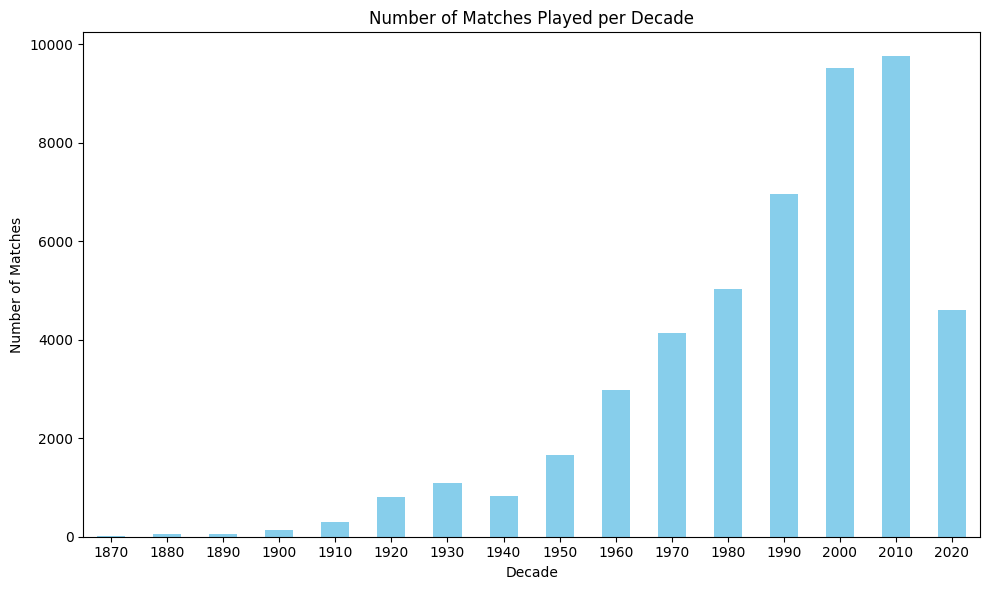

In [ ]:
matches_per_decade = Results.groupby('Decade')['date'].count()
print(matches_per_decade)

# Create a bar chart to visualize the results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
matches_per_decade.plot(kind='bar', color='skyblue')
plt.title('Number of Matches Played per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Matches')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### ¿Qué equipos tienen el mayor rendimiento histórico jugando como local?

home_team
Abkhazia         50.000000
Afghanistan      39.130435
Albania          36.945813
Alderney          2.083333
Algeria          57.440476
                   ...    
Yugoslavia       56.842105
Zambia           55.319149
Zanzibar         29.310345
Zimbabwe         51.269036
Åland Islands    45.161290
Length: 327, dtype: float64

Top 20 Teams by Home Win Percentage:
home_team
Luhansk Pr            100.000000
Western Australia     100.000000
Chameria              100.000000
Central Spain         100.000000
Cascadia              100.000000
Elba Island           100.000000
Franconia             100.000000
Parishes Of Jersey    100.000000
Hmong                 100.000000
Yorkshire              80.000000
Canary Islands         75.000000
Ellan Vannin           75.000000
Rhodes                 72.727273
Padania                71.428571
Brazil                 71.239669
Jersey                 70.078740
Menorca                69.230769
Spain                  68.765743
Northern Cyprus        

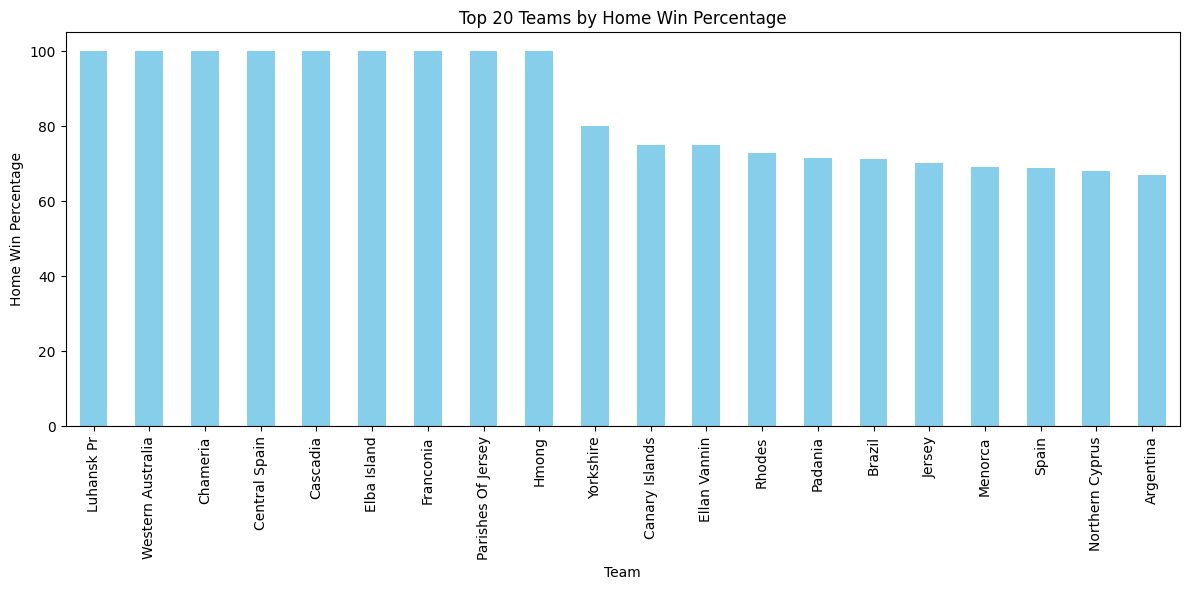

In [ ]:
# Calculate home wins for each team
home_wins_per_team = Results[Results['Win'] == 1].groupby('home_team')['Win'].sum()

# Calculate total home matches for each team
total_home_matches_per_team = Results.groupby('home_team')['home_team'].count()

# Calculate home win percentage
home_win_percentage = (home_wins_per_team / total_home_matches_per_team) * 100

# Print the results
print(home_win_percentage)

# Optional: Sort by win percentage and display top teams
top_teams = home_win_percentage.sort_values(ascending=False).head(20)  # Top 20
print("\nTop 20 Teams by Home Win Percentage:")
print(top_teams)

# Optional: Create a bar chart to visualize the results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
top_teams.plot(kind='bar', color='skyblue')
plt.title('Top 20 Teams by Home Win Percentage')
plt.xlabel('Team')
plt.ylabel('Home Win Percentage')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Presenta gráficos relevantes (barras, histogramas, boxplot, líneas de tiempo).

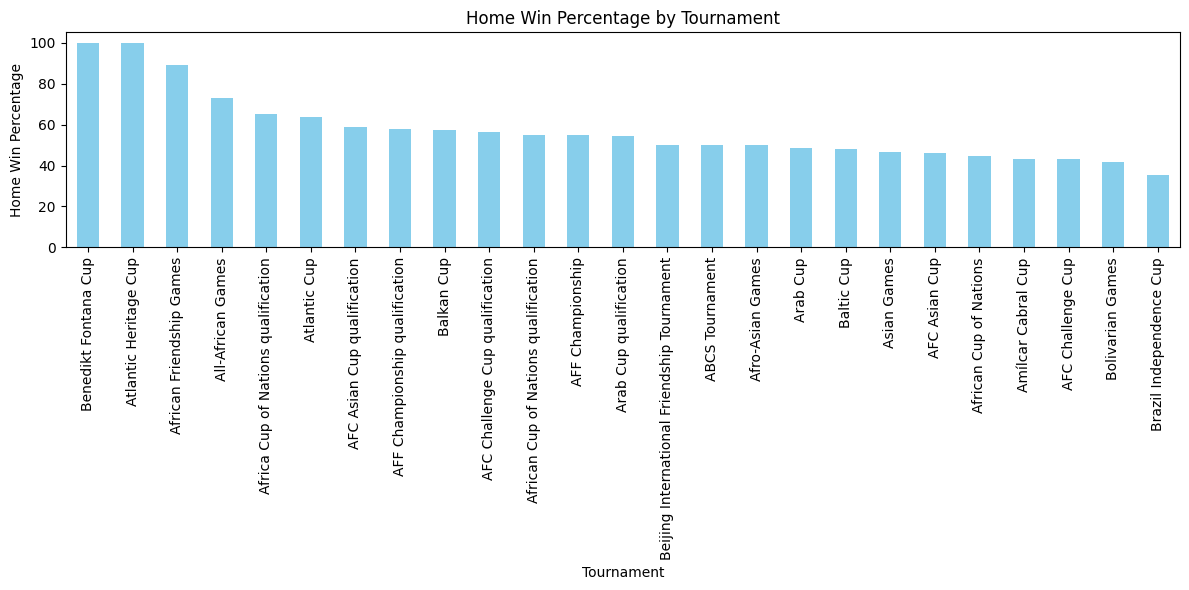

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate home wins for each tournament
home_wins_per_tournament = Results[Results['Win'] == 1].groupby('tournament')['Win'].sum()

# Calculate total home matches for each tournament
total_home_matches_per_tournament = Results.groupby('tournament')['home_team'].count().head(25)

# Calculate home win percentage for each tournament
home_win_percentage_by_tournament = (home_wins_per_tournament / total_home_matches_per_tournament) * 100

# Sort by win percentage (optional)
home_win_percentage_by_tournament = home_win_percentage_by_tournament.sort_values(ascending=False).head(25)

# Create the bar chart
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
home_win_percentage_by_tournament.plot(kind='bar', color='skyblue')
plt.title('Home Win Percentage by Tournament')
plt.xlabel('Tournament')
plt.ylabel('Home Win Percentage')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

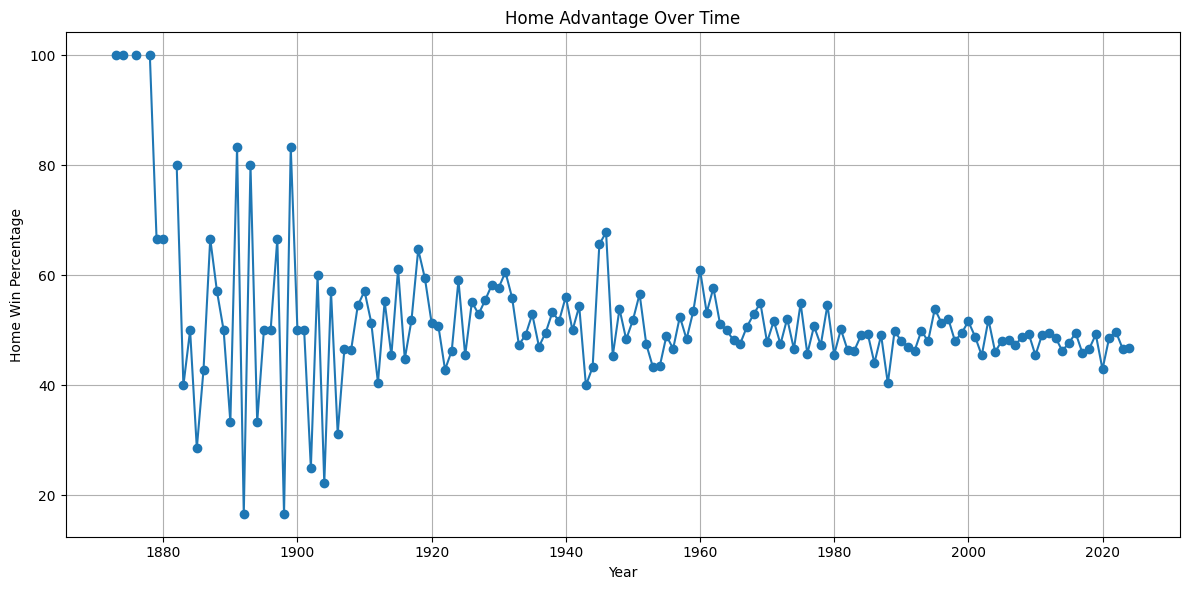

In [ ]:

# Extract the year from the 'date' column
Results['Year'] = Results['date'].dt.year

# Calculate home wins for each year
home_wins_per_year = Results[Results['Win'] == 1].groupby('Year')['Win'].sum()

# Calculate total home matches for each year
total_home_matches_per_year = Results.groupby('Year')['home_team'].count()

# Calculate home win percentage for each year
home_win_percentage_per_year = (home_wins_per_year / total_home_matches_per_year) * 100

# Create the time series plot
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
plt.plot(home_win_percentage_per_year.index, home_win_percentage_per_year.values, marker='o', linestyle='-')
plt.title('Home Advantage Over Time')
plt.xlabel('Year')
plt.ylabel('Home Win Percentage')
plt.grid(True)  # Add a grid for better readability
plt.tight_layout()
plt.show()

### Entrega un informe con análisis descriptivo avanzado, preguntas clave respondidas y graficos relevantes.

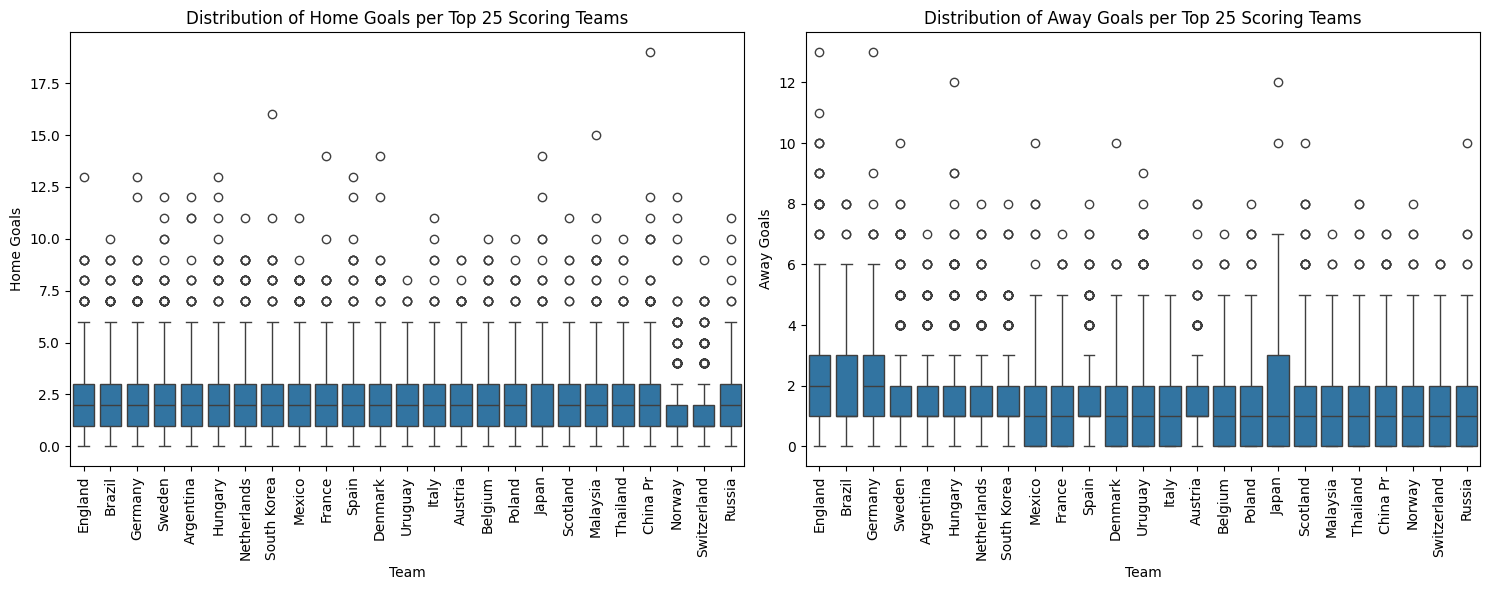

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total goals scored by each team (home + away)
total_goals_per_team = Results.groupby('home_team')['home_score'].sum() + Results.groupby('away_team')['away_score'].sum()
total_goals_per_team = total_goals_per_team.sort_values(ascending=False)  # Sort by total goals

# Get the top 25 scoring teams
top_25_teams = total_goals_per_team.head(25).index

# Filter the DataFrame to include only the top 25 teams
filtered_results = Results[Results['home_team'].isin(top_25_teams) | Results['away_team'].isin(top_25_teams)]

# Create a figure with two subplots (one for home, one for away)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # Adjust figure size as needed

# Box plot for home goals
sns.boxplot(x='home_team', y='home_score', data=filtered_results, order=top_25_teams, ax=axes[0])
axes[0].set_title('Distribution of Home Goals per Top 25 Scoring Teams')
axes[0].set_xlabel('Team')
axes[0].set_ylabel('Home Goals')
axes[0].tick_params(axis='x', rotation=90)  # Rotate x-axis labels

# Box plot for away goals
sns.boxplot(x='away_team', y='away_score', data=filtered_results, order=top_25_teams, ax=axes[1])
axes[1].set_title('Distribution of Away Goals per Top 25 Scoring Teams')
axes[1].set_xlabel('Team')
axes[1].set_ylabel('Away Goals')
axes[1].tick_params(axis='x', rotation=90)  # Rotate x-axis labels

plt.tight_layout()
plt.show()

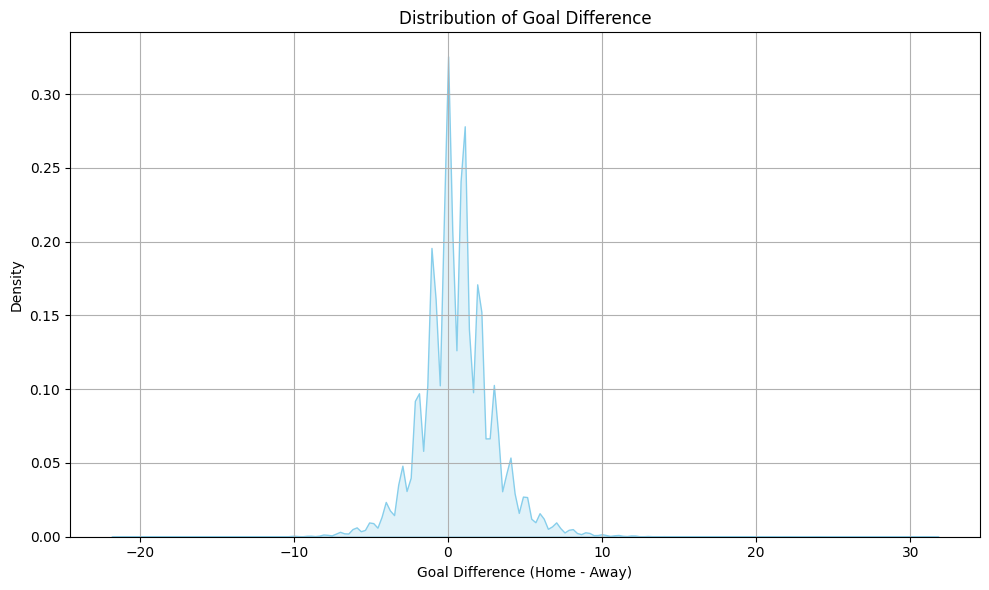

In [ ]:
# Create the density plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
sns.kdeplot(Results['Goal_diff'], fill=True, color='skyblue')
plt.title('Distribution of Goal Difference')
plt.xlabel('Goal Difference (Home - Away)')
plt.ylabel('Density')
plt.grid(True)  # Add a grid for better readability
plt.tight_layout()
plt.show()

## **Reducción de Dimensionalidad**

### Identificación de Necesidades

#### Determina si las variables derivadas son redundantes o altamente correlacionadas.

In [ ]:
Results.head(10)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,is_friendly,Goal_diff,Decade,Win,Year
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,0,Amistoso,0,1870,0,1872
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,0,Amistoso,2,1870,1,1873
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,0,Amistoso,1,1870,1,1874
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,0,Amistoso,0,1870,0,1875
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,0,Amistoso,3,1870,1,1876
5,1876-03-25,Scotland,Wales,4,0,Friendly,Glasgow,Scotland,0,Amistoso,4,1870,1,1876
6,1877-03-03,England,Scotland,1,3,Friendly,London,England,0,Amistoso,-2,1870,0,1877
7,1877-03-05,Wales,Scotland,0,2,Friendly,Wrexham,Wales,0,Amistoso,-2,1870,0,1877
8,1878-03-02,Scotland,England,7,2,Friendly,Glasgow,Scotland,0,Amistoso,5,1870,1,1878
9,1878-03-23,Scotland,Wales,9,0,Friendly,Glasgow,Scotland,0,Amistoso,9,1870,1,1878


In [ ]:
import pandas as pd

# Suponiendo que tu DataFrame se llama 'df'
correlation_matrix = Results[['Goal_diff','Decade','Win','Year']].corr()

# Imprime la matriz de correlación
correlation_matrix

,Goal_diff,Decade,Win,Year
Goal_diff,1.000000,-0.021864,0.716198,-0.022351
Decade,-0.021864,1.000000,-0.023008,0.993665
Win,0.716198,-0.023008,1.000000,-0.022825
Year,-0.022351,0.993665,-0.022825,1.000000


Podemos observar que hay un alto nivel de correlación entre ciartas variables como 'Decade' y 'Year' es decir hay información redundante.

#### Si es necesario, usa el Análisis de Componentes Principales (PCA) para reducir dimensiones mientras mantienes información relevante.

### Pasos de PCA:

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


#### Selecciona variables numéricas derivadas, como goles, diferencias de goles y métricas adicionales.

In [ ]:
# Agrupa por 'home_team' y calcula la media de 'home_score'
home_team_avg_goals = Results.groupby('home_team')['home_score'].mean()

# Crea una nueva columna en el DataFrame original
Results['home_team_avg_goals_scored'] = Results['home_team'].map(home_team_avg_goals)

In [ ]:
# Agrupa por 'away_team' y calcula la media de 'home_score' (goles recibidos)
away_team_avg_goals = Results.groupby('away_team')['away_score'].mean()

# Crea una nueva columna en el DataFrame original
Results['away_team_avg_goals_scored'] = Results['away_team'].map(away_team_avg_goals)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Crea instancias de LabelEncoder para cada variable categórica
encoder_tournament = LabelEncoder()
encoder_city = LabelEncoder()
encoder_is_friendly = LabelEncoder()

# Ajusta los encoders a los datos y transforma las variables
Results['tournament_encoded'] = encoder_tournament.fit_transform(Results['tournament'])
Results['city_encoded'] = encoder_city.fit_transform(Results['city'])
Results['is_friendly_encoded'] = encoder_is_friendly.fit_transform(Results['is_friendly'])

In [ ]:
#Selecciono las variables y las estandarizo
X = Results[['tournament_encoded', 'city_encoded',
            'is_friendly_encoded','home_team_avg_goals_scored','away_team_avg_goals_scored' , 'Year']]
x = StandardScaler().fit_transform(X)

#### Calcula la varianza explicada por cada componente principal.

In [ ]:
#Selecciono la cantidad de componentes principales
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x)
principalDf = pd.DataFrame(data = principalComponents, columns = ['componente 1', 'componente 2'])
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance_ratio)


Explained Variance Ratio: [0.25327817 0.1804372 ]


#### Visualiza los dos primeros componentes para identificar patrones históricos o grupales.

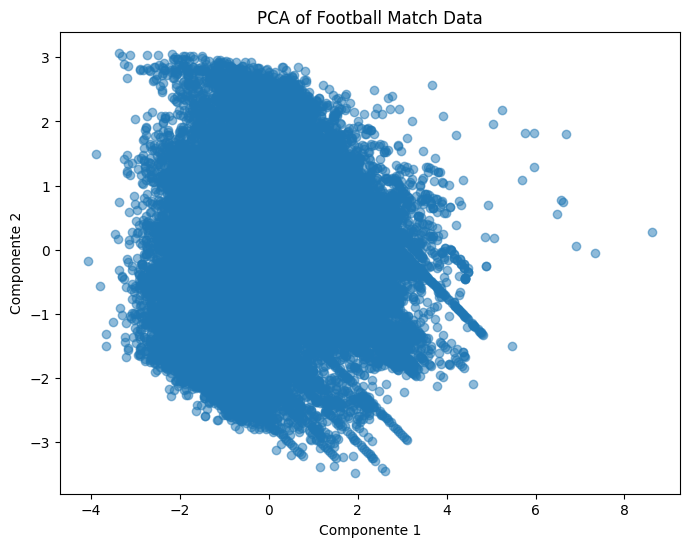

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Visualizacion
plt.figure(figsize=(8, 6))
plt.scatter(principalDf['componente 1'], principalDf['componente 2'], alpha=0.5)
plt.title('PCA of Football Match Data')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.show()

### Aplicación del modelado

#### Utiliza las dimensiones reducidas como insumos para modelos predictivos.

In [ ]:
#Voy a ver como funcionan las varibales reducidad en la predicción de 'Win' con una regresión logística
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Prepare the data
X_pca = principalDf[['componente 1', 'componente 2']]  # Reduced dimensions
y = Results['Win']  # Target variable (home team win or not)

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# 3. Create and train the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = model.predict(X_test)

# 5. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))


Accuracy: 0.5291110183639399
              precision    recall  f1-score   support

           0       0.53      0.69      0.60      4874
           1       0.53      0.36      0.43      4710

    accuracy                           0.53      9584
   macro avg       0.53      0.53      0.51      9584
weighted avg       0.53      0.53      0.52      9584



/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


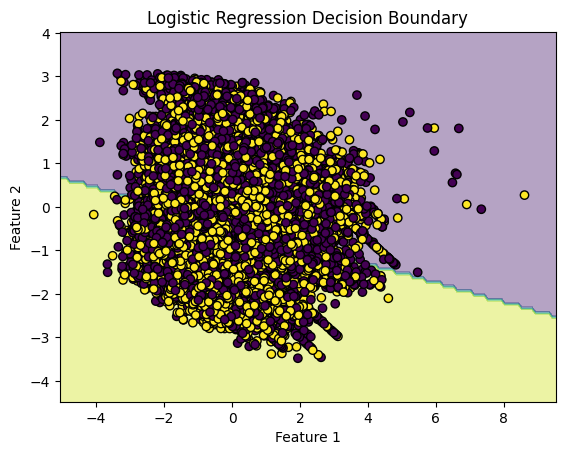

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Assuming you have already trained your model and have X_train, X_test, y_train, y_test

# Create a meshgrid to plot the decision boundary
x_min, x_max = X_train.iloc[:, 0].min() - 1, X_train.iloc[:, 0].max() + 1
y_min, y_max = X_train.iloc[:, 1].min() - 1, X_train.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict the class probabilities for the meshgrid points
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.4)

# Plot the training data points
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train, edgecolors='k')

plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Entrega:


#### Visualizaciones del PCA y justificación del uso de dimensiones seleccionadas.

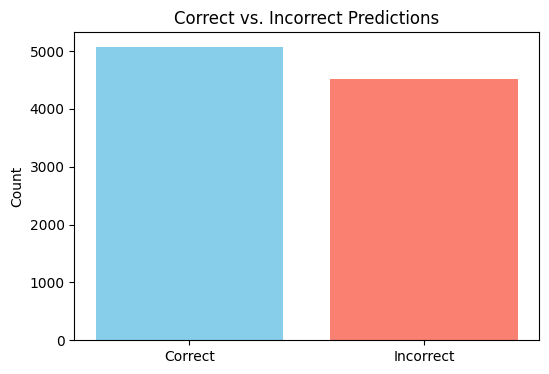

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Assuming you have y_test (actual values) and y_pred (predicted values)
# and y_pred might be continuous (e.g., probabilities)

# Convert y_pred to binary labels (0 or 1) based on a threshold
threshold = 0.5  # Adjust the threshold as needed
y_pred_binary = (y_pred > threshold).astype(int)

# Calculate the confusion matrix using the binary predictions
cm = confusion_matrix(y_test, y_pred_binary)

# Get the counts of correct and incorrect predictions
correct_predictions = np.trace(cm)  # Sum of diagonal elements (correct predictions)
incorrect_predictions = np.sum(cm) - correct_predictions

# Create the bar plot
plt.figure(figsize=(6, 4))
plt.bar(['Correct', 'Incorrect'], [correct_predictions, incorrect_predictions], color=['skyblue', 'salmon'])
plt.title('Correct vs. Incorrect Predictions')
plt.ylabel('Count')
plt.show()



---
---



#***Análisis Avanzado y Modelos predictivos***

## **Ventaja de Localía y Probabilidades Condicionales (1 puntos)**

### Usa el teorema de Bayes para calcular:

In [ ]:
from re import A
#Defino mis eventos
#El equipo gana
A = Results['home_score'] > Results['away_score']
#El equipo juega como local
B = True

#### La probabilidad de que un equipo gane si juega como local.

In [ ]:
#Probabilidad de que un equipo gane
P_A = A.mean()
#Probabilidad de que un equipo juegue como local
P_B = B

In [ ]:
# Calcula las probabilidades condicionales
P_B_given_A = (A & B).mean() / P_A  # Probabilidad de que un equipo juegue como local dado que ganó

# Aplica el teorema de Bayes
P_A_given_B = (P_B_given_A * P_A) / P_B  # Probabilidad de que un equipo gane dado que juega como local

# Imprime el resultado
print(f"La probabilidad de que un equipo gane si juega como local es: {P_A_given_B}")

La probabilidad de que un equipo gane si juega como local es: 0.4900974601915813


#### La probabilidad de empate en un campo neutral.

In [ ]:
#Empate en un campo neutral
C = Results['home_score'] == Results['away_score']
D = Results['neutral'] == True

In [ ]:
#Probabilidad de empate independientemente donde juegen
P_C = C.mean()
#Probabilidad de que jueguen en un campo neutral
P_D = D.mean()

In [ ]:
#Probabilidades condicionadas
P_C_given_D = (C & D).mean() / P_D
#Teorema de Bayes
P_D_given_C = (P_C_given_D * P_D) / P_C
print('La probabilidad de empate en campo neutral es de ' + str(P_D_given_C))

La probabilidad de empate en campo neutral es de 0.2588515868647955


#### Probabilidad de que un partido sea emocionante

In [ ]:
# Ejemplo: Probabilidad a priori de que un partido tenga más de 3 goles
X = 3  # Umbral para un partido emocionante
total_matches = Results.shape[0]
exciting_matches = Results[(Results['home_score'] + Results['away_score']) > X].shape[0]
P_A = exciting_matches / total_matches

In [ ]:
# Ejemplo: Verosimilitud de que el partido sea entre Equipo1 y Equipo2 dado que tuvo más de 3 goles
exciting_matches_condition_B = Results[
    ((Results['home_score'] + Results['away_score']) > X) &
    ((Results['home_team'] == 'Argentina') & (Results['away_team'] == 'Uruguay') |
     (Results['home_team'] == 'Uruguay') & (Results['away_team'] == 'Argentina'))
].shape[0]

P_B_given_A = exciting_matches_condition_B / exciting_matches



In [ ]:
# Probabilidad posterior P(A|B)
P_A_given_B = (P_B_given_A * P_A) / P_B
print(f"Probabilidad de un partido emocionante entre Argentina y Uruguay: {P_A_given_B}")

Probabilidad de un partido emocionante entre Argentina y Uruguay: 0.001189556942212576


### Representa tus hallazgos en tablas y gráficos explicativos.

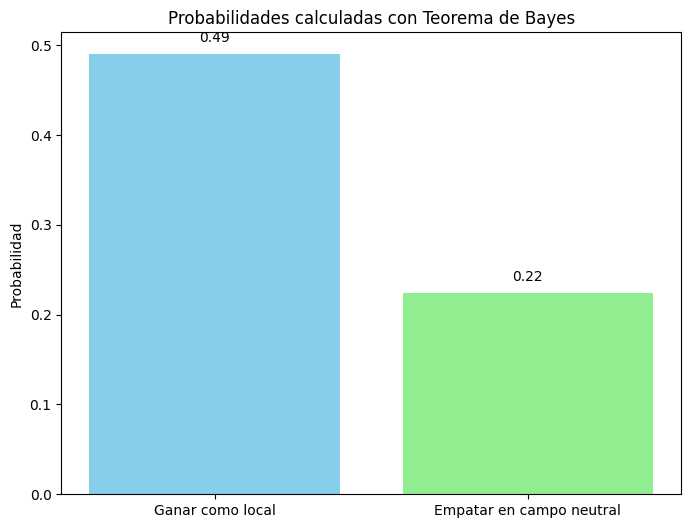

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Calcula la probabilidad de ganar como local
home_wins = Results[Results['home_score'] > Results['away_score']].shape[0]
total_matches = Results.shape[0]
prob_win_home = home_wins / total_matches

# Calcula la probabilidad de empate en campo neutral
neutral_draws = Results[(Results['home_score'] == Results['away_score']) & (Results['neutral'] == True)].shape[0]
neutral_matches = Results[Results['neutral'] == True].shape[0]
prob_draw_neutral = neutral_draws / neutral_matches

# Crea el gráfico de barras
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(['Ganar como local', 'Empatar en campo neutral'], [prob_win_home, prob_draw_neutral], color=['skyblue', 'lightgreen'])
ax.set_ylabel('Probabilidad')
ax.set_title('Probabilidades calculadas con Teorema de Bayes')

# Agrega etiquetas con los valores de probabilidad
for i, v in enumerate([prob_win_home, prob_draw_neutral]):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom')

plt.show()

## **Modelos de clasificación (2 puntos)**

### Diseña un modelo para predecir el resultado de un partido (home_win, draw, away_win):

In [ ]:
Results.head(10)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,is_friendly,Goal_diff,Decade,Win,Year,home_team_avg_goals_scored,away_team_avg_goals_scored,tournament_encoded,city_encoded,is_friendly_encoded
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,0,Amistoso,0,1870,0,1872,1.897059,2.078358,85,657,0
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,0,Amistoso,2,1870,1,1873,2.288889,1.522145,85,1037,0
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,0,Amistoso,1,1870,1,1874,1.897059,2.078358,85,657,0
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,0,Amistoso,0,1870,0,1875,2.288889,1.522145,85,1037,0
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,0,Amistoso,3,1870,1,1876,1.897059,2.078358,85,657,0
5,1876-03-25,Scotland,Wales,4,0,Friendly,Glasgow,Scotland,0,Amistoso,4,1870,1,1876,1.897059,1.047222,85,657,0
6,1877-03-03,England,Scotland,1,3,Friendly,London,England,0,Amistoso,-2,1870,0,1877,2.288889,1.522145,85,1037,0
7,1877-03-05,Wales,Scotland,0,2,Friendly,Wrexham,Wales,0,Amistoso,-2,1870,0,1877,1.443182,1.522145,85,2012,0
8,1878-03-02,Scotland,England,7,2,Friendly,Glasgow,Scotland,0,Amistoso,5,1870,1,1878,1.897059,2.078358,85,657,0
9,1878-03-23,Scotland,Wales,9,0,Friendly,Glasgow,Scotland,0,Amistoso,9,1870,1,1878,1.897059,1.047222,85,657,0


#### Selecciona variables relevantes como el torneo, localización, y goles anteriores.

Relación entre variables numéricas de mi DF

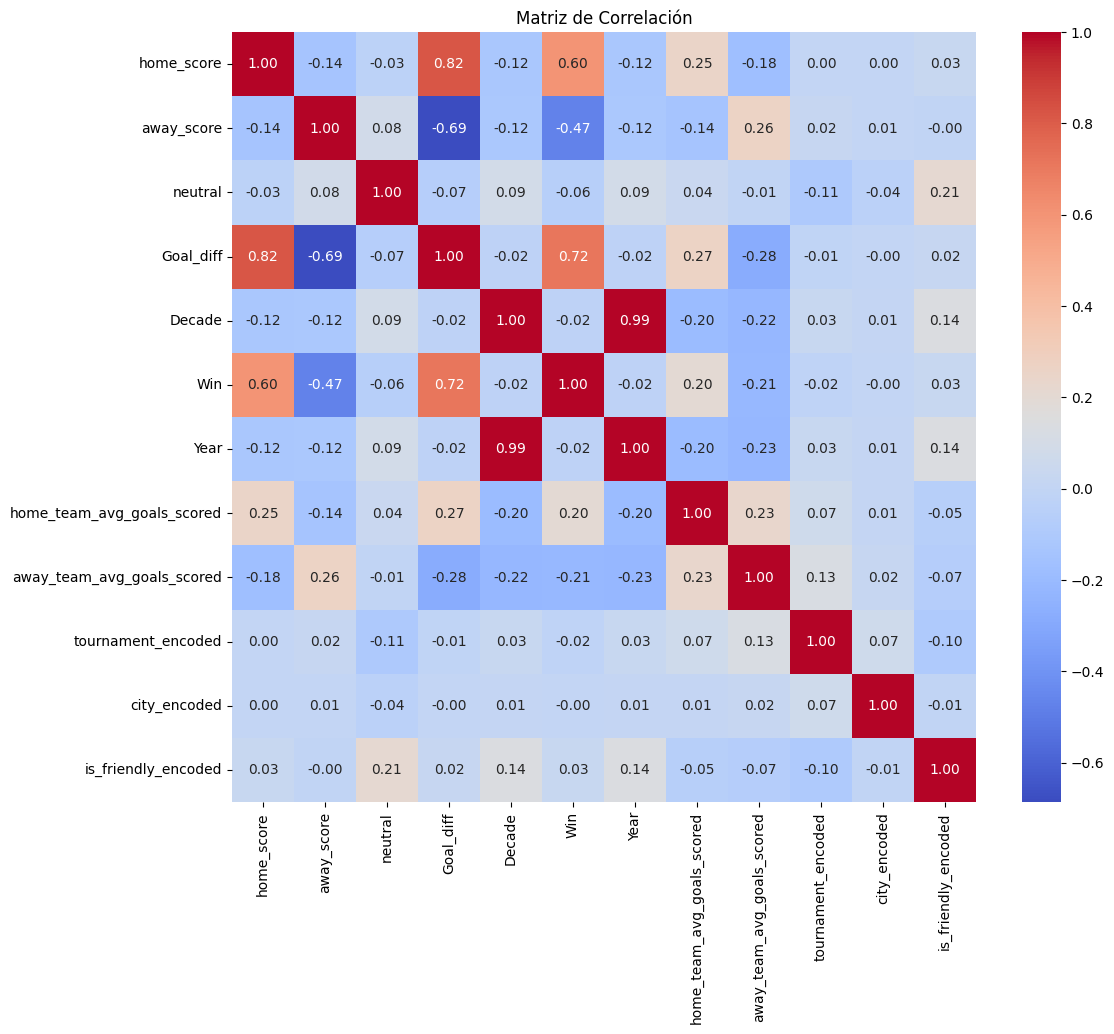

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for correlation analysis
numerical_cols = Results.select_dtypes(include=['number']).columns
correlation_matrix = Results[numerical_cols].corr()

# Now you can create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

In [ ]:
import pandas as pd

def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'home_win'
    elif row['home_score'] < row['away_score']:
        return 'away_win'
    else:
        return 'draw'

# Apply the function to create the 'result' column
Results['result'] = Results.apply(get_result, axis=1)

Nuestras variables Home score y Away score tienen una relación alta con result. Goaldiff es esencialmete una representación de la varuable que queremos predecir. La eliminamos.

Probamos Un RANDOM FOREST

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier  # Import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# 1. Prepare the data
# ... (Your existing code to define get_result and apply it) ...
# Assuming 'Results' is your DataFrame
home_team_wins = Results[Results['home_score'] > Results['away_score']].groupby('home_team')['home_team'].count()
home_team_total_matches = Results.groupby('home_team')['home_team'].count()
home_team_win_rate = (home_team_wins / home_team_total_matches).fillna(0)  # Handle cases with no wins

    # Add the win rate as a feature to your DataFrame
Results['home_team_win_rate'] = Results['home_team'].map(home_team_win_rate)

away_team_wins = Results[Results['away_score'] > Results['home_score']].groupby('away_team')['away_team'].count()
away_team_total_matches = Results.groupby('away_team')['away_team'].count()
away_team_win_rate = (away_team_wins / away_team_total_matches).fillna(0)  # Handle cases with no wins

Results['away_team_win_rate'] = Results['away_team'].map(away_team_win_rate)

# Select relevant columns including 'home_team' and 'away_team'
features = ['city', 'tournament', 'Year', 'home_team', 'away_team', 'is_friendly','home_team_win_rate', 'away_team_win_rate']
target = 'result'

# Create a LabelEncoder for categorical variables
encoder = LabelEncoder()
for col in ['city', 'tournament', 'home_team', 'away_team', 'is_friendly']:
    Results[col + '_encoded'] = encoder.fit_transform(Results[col])


# Select relevant columns including 'home_team' and 'away_team'
features = ['city_encoded', 'tournament_encoded', 'Year', 'home_team_encoded', 'away_team_encoded', 'is_friendly_encoded','home_team_win_rate', 'away_team_win_rate']
target = 'result'

# Create the feature matrix (X) and target vector (y)
X = Results[features]
y = Results[target]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identify numerical features
numerical_features = ['Year','home_team_win_rate', 'away_team_win_rate' ]  # Add any other numerical features you have

# Create a StandardScaler instance
scaler = StandardScaler()

# Fit and transform only numerical features in the training set
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])

# Transform numerical features in the testing set using the fitted scaler
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

# Create and train the Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 4. Make predictions on the test set
y_pred = model.predict(X_test)

# 5. Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.5291110183639399
              precision    recall  f1-score   support

    away_win       0.51      0.49      0.50      2690
        draw       0.30      0.18      0.23      2184
    home_win       0.62      0.75      0.68      4710

    accuracy                           0.54      9584
   macro avg       0.48      0.47      0.47      9584
weighted avg       0.51      0.54      0.52      9584



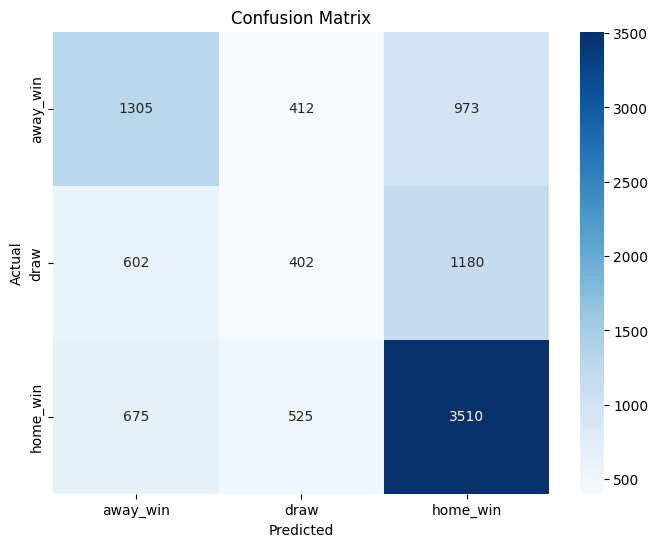

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# ... (Your existing code to prepare and train the Random Forest model) ...

# Assuming you have already trained the model and have X_train, X_test, y_train, y_test
# and made predictions on the test set: y_pred = model.predict(X_test)

# Get the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)  # Use model.classes_ for labels
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Aplico mi modelo a un set nuevo de partidos

PRUEBO UNA REGRESIÓN LOGÍSTICA

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Assuming 'Results' is your DataFrame
home_team_wins = Results[Results['home_score'] > Results['away_score']].groupby('home_team')['home_team'].count()
home_team_total_matches = Results.groupby('home_team')['home_team'].count()
home_team_win_rate = (home_team_wins / home_team_total_matches).fillna(0)  # Handle cases with no wins

    # Add the win rate as a feature to your DataFrame
Results['home_team_win_rate'] = Results['home_team'].map(home_team_win_rate)

away_team_wins = Results[Results['away_score'] > Results['home_score']].groupby('away_team')['away_team'].count()
away_team_total_matches = Results.groupby('away_team')['away_team'].count()
away_team_win_rate = (away_team_wins / away_team_total_matches).fillna(0)  # Handle cases with no wins

Results['away_team_win_rate'] = Results['away_team'].map(away_team_win_rate)

# 1. Feature Engineering and Selection
features = ['home_team_win_rate', 'away_team_win_rate',
            'tournament_encoded', 'city_encoded', 'is_friendly_encoded']
target = 'result'

# Create LabelEncoders for categorical features
encoder_tournament = LabelEncoder()
encoder_city = LabelEncoder()
encoder_is_friendly = LabelEncoder()

# Fit and transform categorical features in 'Results' DataFrame
Results['tournament_encoded'] = encoder_tournament.fit_transform(Results['tournament'])
Results['city_encoded'] = encoder_city.fit_transform(Results['city'])
Results['is_friendly_encoded'] = encoder_is_friendly.fit_transform(Results['is_friendly'])

# 2. Data Preparation
X = Results[features]
y = Results[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Escalado de datos (opcional, pero recomendado para Regresión Logística)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Model Training and Evaluation
model = LogisticRegression(max_iter=1000, multi_class='ovr')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate the model
accuracy_rl = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.5291110183639399
              precision    recall  f1-score   support

    away_win       0.50      0.49      0.50      2690
        draw       0.00      0.00      0.00      2184
    home_win       0.58      0.85      0.69      4710

    accuracy                           0.56      9584
   macro avg       0.36      0.45      0.39      9584
weighted avg       0.42      0.56      0.48      9584

[[1315    0 1375]
 [ 605    0 1579]
 [ 690    0 4020]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


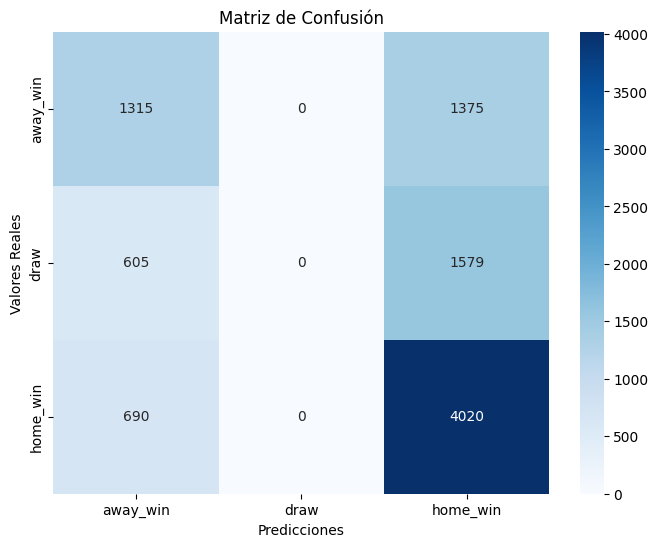

In [ ]:

# Obtener las predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Plotear la matriz de confusión utilizando seaborn
plt.figure(figsize=(8, 6))  # Ajustar el tamaño de la figura si es necesario
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Matriz de Confusión")
plt.xlabel("Predicciones")
plt.ylabel("Valores Reales")
plt.show()

#### Usa un modelo simple como árboles de decisión, regresión logística o clasificación bayesiana.

Modelo Clasificación BAYESIANA

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# 1. Feature Engineering and Selection
features = ['tournament_encoded', 'city_encoded', 'is_friendly_encoded', 'home_score_cat', 'away_score_cat']
target = 'result'

# Create LabelEncoders for categorical features (if not already created)
encoder_tournament = LabelEncoder()
encoder_city = LabelEncoder()
encoder_is_friendly = LabelEncoder()

# Fit and transform categorical features in 'Results' DataFrame
Results['tournament_encoded'] = encoder_tournament.fit_transform(Results['tournament'])
Results['city_encoded'] = encoder_city.fit_transform(Results['city'])
Results['is_friendly_encoded'] = encoder_is_friendly.fit_transform(Results['is_friendly'])

# Discretize home_score and away_score into categories (bins)
# You can adjust the bins according to your data distribution
Results['home_score_cat'] = pd.cut(Results['home_score'], bins=[-1, 0, 1, 2, 3, float('inf')], labels=[0, 1, 2, 3, 4])
Results['away_score_cat'] = pd.cut(Results['away_score'], bins=[-1, 0, 1, 2, 3, float('inf')], labels=[0, 1, 2, 3, 4])

# 2. Data Preparation
X = Results[features]
y = Results[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training and Evaluation
model = CategoricalNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate the model
accuracy_nb = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))




Accuracy: 0.5291110183639399
              precision    recall  f1-score   support

    away_win       0.93      0.86      0.89      2690
        draw       0.73      0.66      0.70      2184
    home_win       0.89      0.97      0.92      4710

    accuracy                           0.87      9584
   macro avg       0.85      0.83      0.84      9584
weighted avg       0.86      0.87      0.86      9584



In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
print(confusion_matrix(y_test, y_pred))
f1 = f1_score(y_test, y_pred, average='weighted')  # Use 'weighted' for multi-class
print("F1-score:", f1)


[[2309  369   12]
 [ 171 1444  569]
 [   3  157 4550]]
F1-score: 0.863432362280119


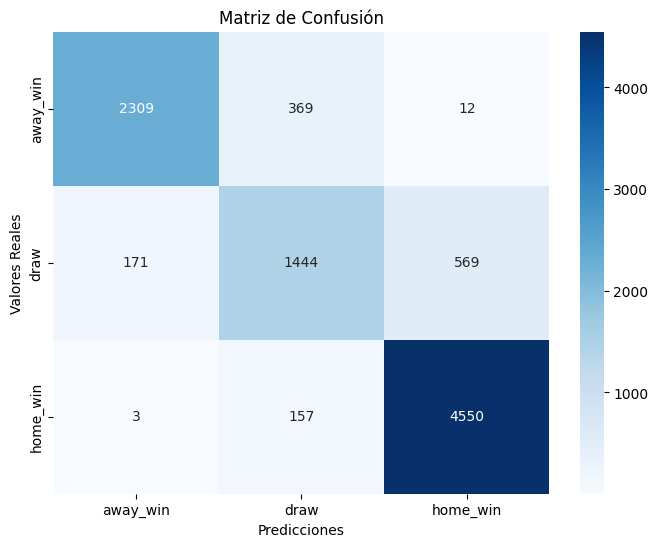

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ... (código para entrenar y evaluar tu modelo NB) ...

# Obtener las predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Plotear la matriz de confusión utilizando seaborn
plt.figure(figsize=(8, 6))  # Ajustar el tamaño de la figura si es necesario
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Matriz de Confusión")
plt.xlabel("Predicciones")
plt.ylabel("Valores Reales")
plt.show()

#### Evalúa el desempeño del modelo con métricas como precisión, F1 score y matriz de confusión.

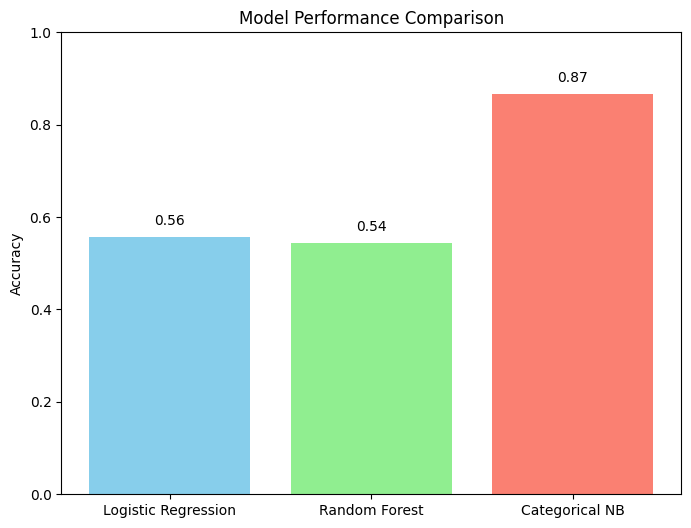

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have calculated accuracy scores for each model
# and stored them in variables like:


models = ['Logistic Regression', 'Random Forest', 'Categorical NB']
accuracies = [accuracy_rl, accuracy_rf, accuracy_nb]

# Create bar chart
plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Model Performance Comparison')
plt.ylabel('Accuracy')
plt.ylim([0, 1])  # Set y-axis limits for better visualization

# Add accuracy values on top of bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f'{v:.2f}', ha='center', va='bottom')

plt.show()

**Are we overfitting using home score and away score in the case of logistic regression**

There is a significant risk of overfitting when using home_score and away_score directly as features in a logistic regression model to predict the outcome of football matches. This is because these features are very closely related to the target variable (the match outcome).

Explanation

Direct Relationship: home_score and away_score inherently determine the outcome of the match. If the home_score is greater than the away_score, the home team wins. If they are equal, it's a draw. And if the away_score is greater, the away team wins.
Leakage of Target Information: By including these features directly, you're essentially giving the model the answer in a slightly disguised form. The model will easily learn to perfectly predict the outcome on the training data, but it won't generalize well to new, unseen matches.



**Is it better to use a Categorical NB while using those two variables to avoid overfitting?**

Using a Categorical Naive Bayes (CategoricalNB) model with discretized versions of home_score and away_score is generally a better approach to avoid overfitting compared to using them directly in Logistic Regression.

Here's why:

Discretization Reduces Overfitting: By converting the continuous home_score and away_score into categorical bins (e.g., 0-1 goals, 2-3 goals, etc.), you reduce the model's sensitivity to small changes in these features. This helps prevent it from memorizing the exact scores and encourages it to learn more general patterns.

Naive Bayes Assumption: The Naive Bayes assumption, while often considered a simplification, can actually act as a form of regularization. It assumes that features are independent of each other, which can prevent the model from becoming too complex and overfitting to the training data.

### Entrega un informe en .pdf (máximo 3 páginas) con los pasos, resultados y gráficos de evaluación.

---
---

# ***Redes y Técnicas Avanzadas***

## **Análisis de Grafos (2 puntos)**

### Crea un grafo donde:

#### Los nodos representen equipos

#### Un Grafo general

In [ ]:
import networkx as nx

# Crea un grafo dirigido
grafo = nx.DiGraph()

# Agrega nodos (equipos) y aristas (partidos)
for _, row in Results.iterrows():
    grafo.add_edge(row['home_team'], row['away_team'], weight=row['home_score'] - row['away_score'])  # Diferencia de goles como peso

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# ... (Código para construir el grafo, como en la respuesta anterior) ...

# Visualiza el grafo
plt.figure(figsize=(50, 50))  # Ajusta el tamaño de la figura si es necesario
nx.draw(grafo, with_labels=True, node_color='skyblue', node_size=1500, font_size=17, edge_color='gray')
plt.title("Grafo de Partidos de Fútbol")
plt.show()

In [ ]:
# Número de nodos (equipos)
num_nodos = grafo.number_of_nodes()
print("Número de nodos:", num_nodos)

# Número de aristas (partidos)
num_aristas = grafo.number_of_edges()
print("Número de aristas:", num_aristas)

# Grado promedio
grado_promedio = sum(dict(grafo.degree()).values()) / num_nodos
print("Grado promedio:", grado_promedio)

# Densidad del grafo
densidad = nx.density(grafo)
print("Densidad:", densidad)

# Diámetro del grafo (si es conexo)
if nx.is_connected(grafo.to_undirected()):  # Convierte a no dirigido para el diámetro
    diametro = nx.diameter(grafo.to_undirected())
    print("Diámetro:", diametro)
else:
    print("El grafo no es conexo, no se puede calcular el diámetro.")

# Clustering coefficient (coeficiente de agrupamiento) promedio
clustering_promedio = nx.average_clustering(grafo)
print("Clustering coefficient promedio:", clustering_promedio)

# Otras métricas
# ... (Puedes agregar más métricas según tus necesidades)

In [ ]:
# Número de nodos (equipos)
num_nodos = grafo.number_of_nodes()
print("Número de nodos:", num_nodos)

# Número de aristas (partidos)
num_aristas = grafo.number_of_edges()
print("Número de aristas:", num_aristas)

# Grado promedio
grado_promedio = sum(dict(grafo.degree()).values()) / num_nodos
print("Grado promedio:", grado_promedio)

# Densidad del grafo
densidad = nx.density(grafo)
print("Densidad:", densidad)

# Diámetro del grafo (si es conexo)
if nx.is_connected(grafo.to_undirected()):  # Convierte a no dirigido para el diámetro
    diametro = nx.diameter(grafo.to_undirected())
    print("Diámetro:", diametro)
else:
    print("El grafo no es conexo, no se puede calcular el diámetro.")

# Clustering coefficient (coeficiente de agrupamiento) promedio
clustering_promedio = nx.average_clustering(grafo)
print("Clustering coefficient promedio:", clustering_promedio)

# Otras métricas
# ... (Puedes agregar más métricas según tus necesidades)

In [ ]:
import networkx as nx

# ... (Código para construir el grafo, como en la respuesta anterior) ...

# Centralidad de grado
centralidad_grado = nx.degree_centrality(grafo)
# Los nodos con mayor centralidad de grado tienen más conexiones (partidos jugados).

# Centralidad de intermediación
centralidad_intermediacion = nx.betweenness_centrality(grafo)
# Los nodos con mayor centralidad de intermediación están en más caminos cortos entre otros nodos.

# Centralidad de cercanía
centralidad_cercania = nx.closeness_centrality(grafo)
# Los nodos con mayor centralidad de cercanía están, en promedio, más cerca de todos los demás nodos.

# Centralidad de vector propio
centralidad_vector_propio = nx.eigenvector_centrality(grafo)
# Los nodos con mayor centralidad de vector propio están conectados a otros nodos importantes.

# Grado de los nodos
grado_nodos = dict(grafo.degree())
# El grado de un nodo es el número de conexiones que tiene.

# Componentes conectados
componentes_conectados = list(nx.connected_components(grafo.to_undirected()))
# Los componentes conectados son grupos de nodos que están conectados entre sí.

# Imprime las métricas
print("Centralidad de grado:", centralidad_grado)
print("Centralidad de intermediación:", centralidad_intermediacion)
print("Centralidad de cercanía:", centralidad_cercania)
print("Centralidad de vector propio:", centralidad_vector_propio)
print("Grado de los nodos:", grado_nodos)
print("Componentes conectados:", componentes_conectados)


# Identifica equipos clave (por ejemplo, los 10 con mayor centralidad de grado)
equipos_clave_grado = sorted(centralidad_grado, key=centralidad_grado.get, reverse=True)[:10]
print("Equipos clave por centralidad de grado:", equipos_clave_grado)

# ... (Puedes agregar más lógica para identificar equipos clave según otras métricas) ...

In [ ]:
import pandas as pd
import networkx as nx

# ... (Código para construir el grafo y calcular las métricas, como en la respuesta anterior) ...

# Crea un DataFrame con las métricas
metricas = pd.DataFrame({
    'Equipo': list(grafo.nodes()),
    'Centralidad de Grado': list(centralidad_grado.values()),
    'Centralidad de Intermediación': list(centralidad_intermediacion.values()),
    'Centralidad de Cercanía': list(centralidad_cercania.values()),
    'Centralidad de Vector Propio': list(centralidad_vector_propio.values()),
    'Grado': list(grado_nodos.values())
})

# Ordena la tabla por centralidad de grado (opcional)
metricas = metricas.sort_values(by=['Centralidad de Grado'], ascending=False)

# Muestra la tabla
print(metricas)

# Puedes guardar la tabla en un archivo CSV si lo deseas
# metricas.to_csv('metricas_grafo.csv', index=False)

### Calcula métricas como centralidad, grado y componentes conectados para identificar equipos clave.

### POr torneos

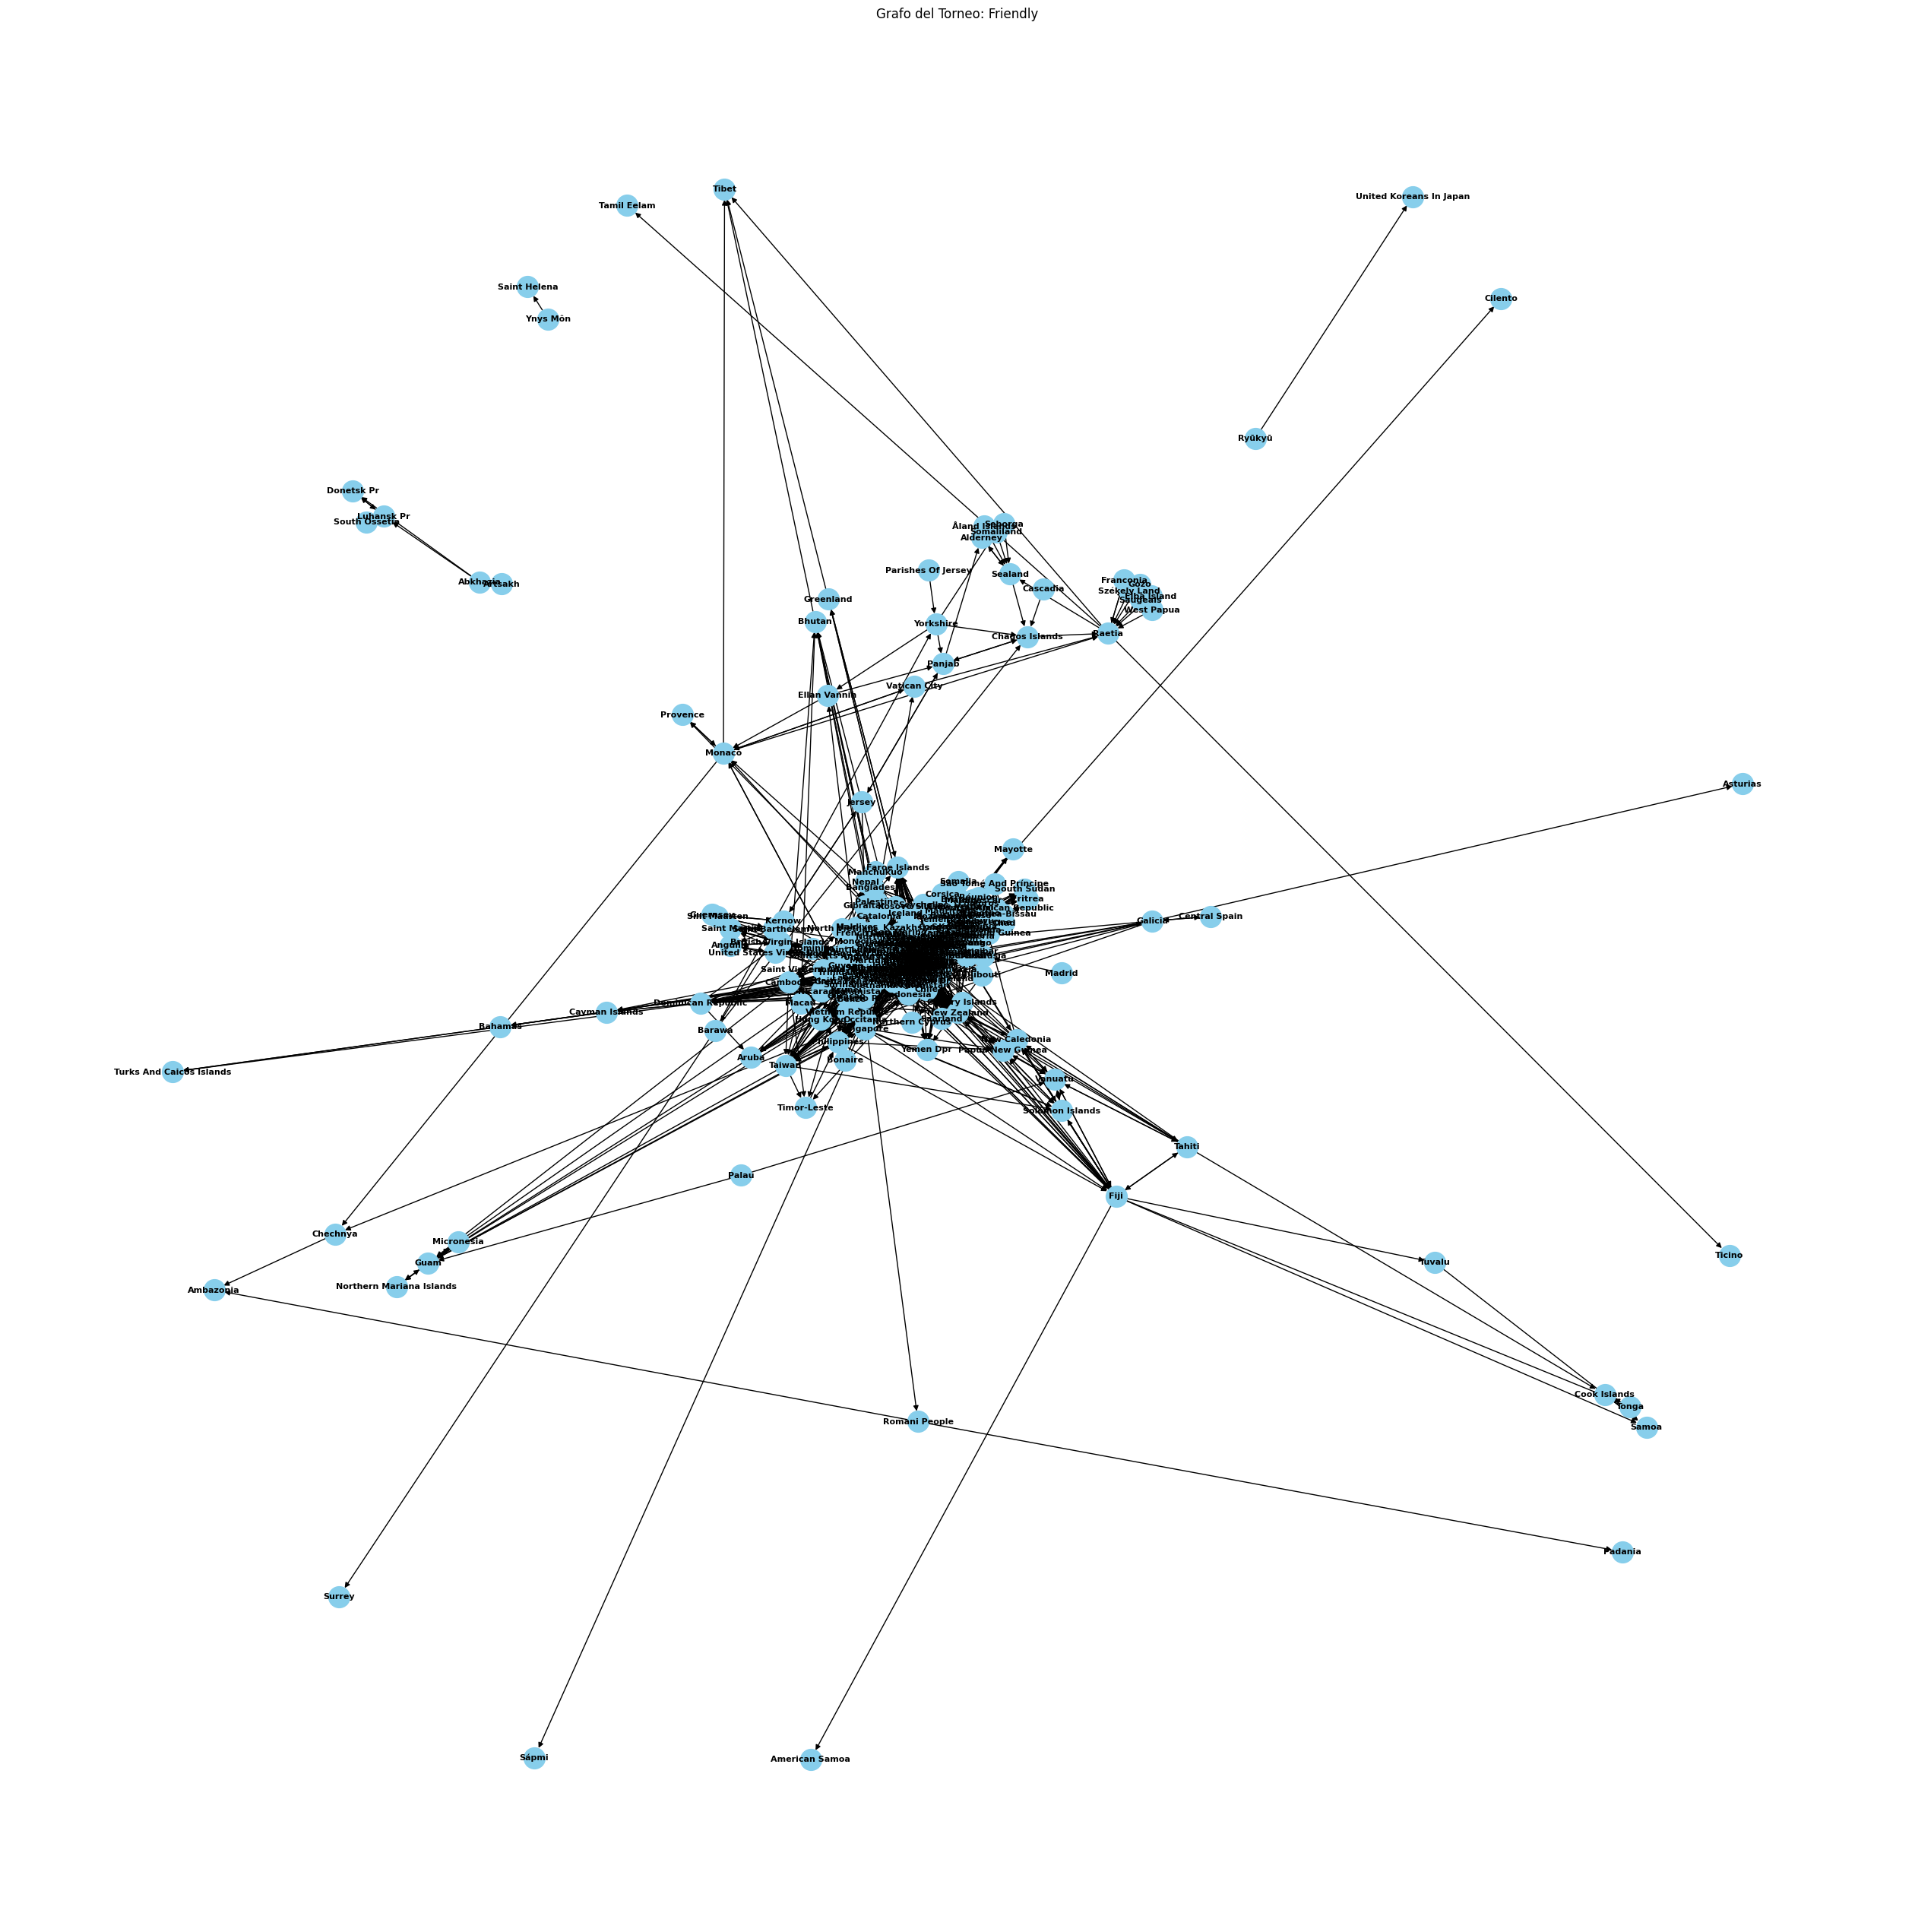

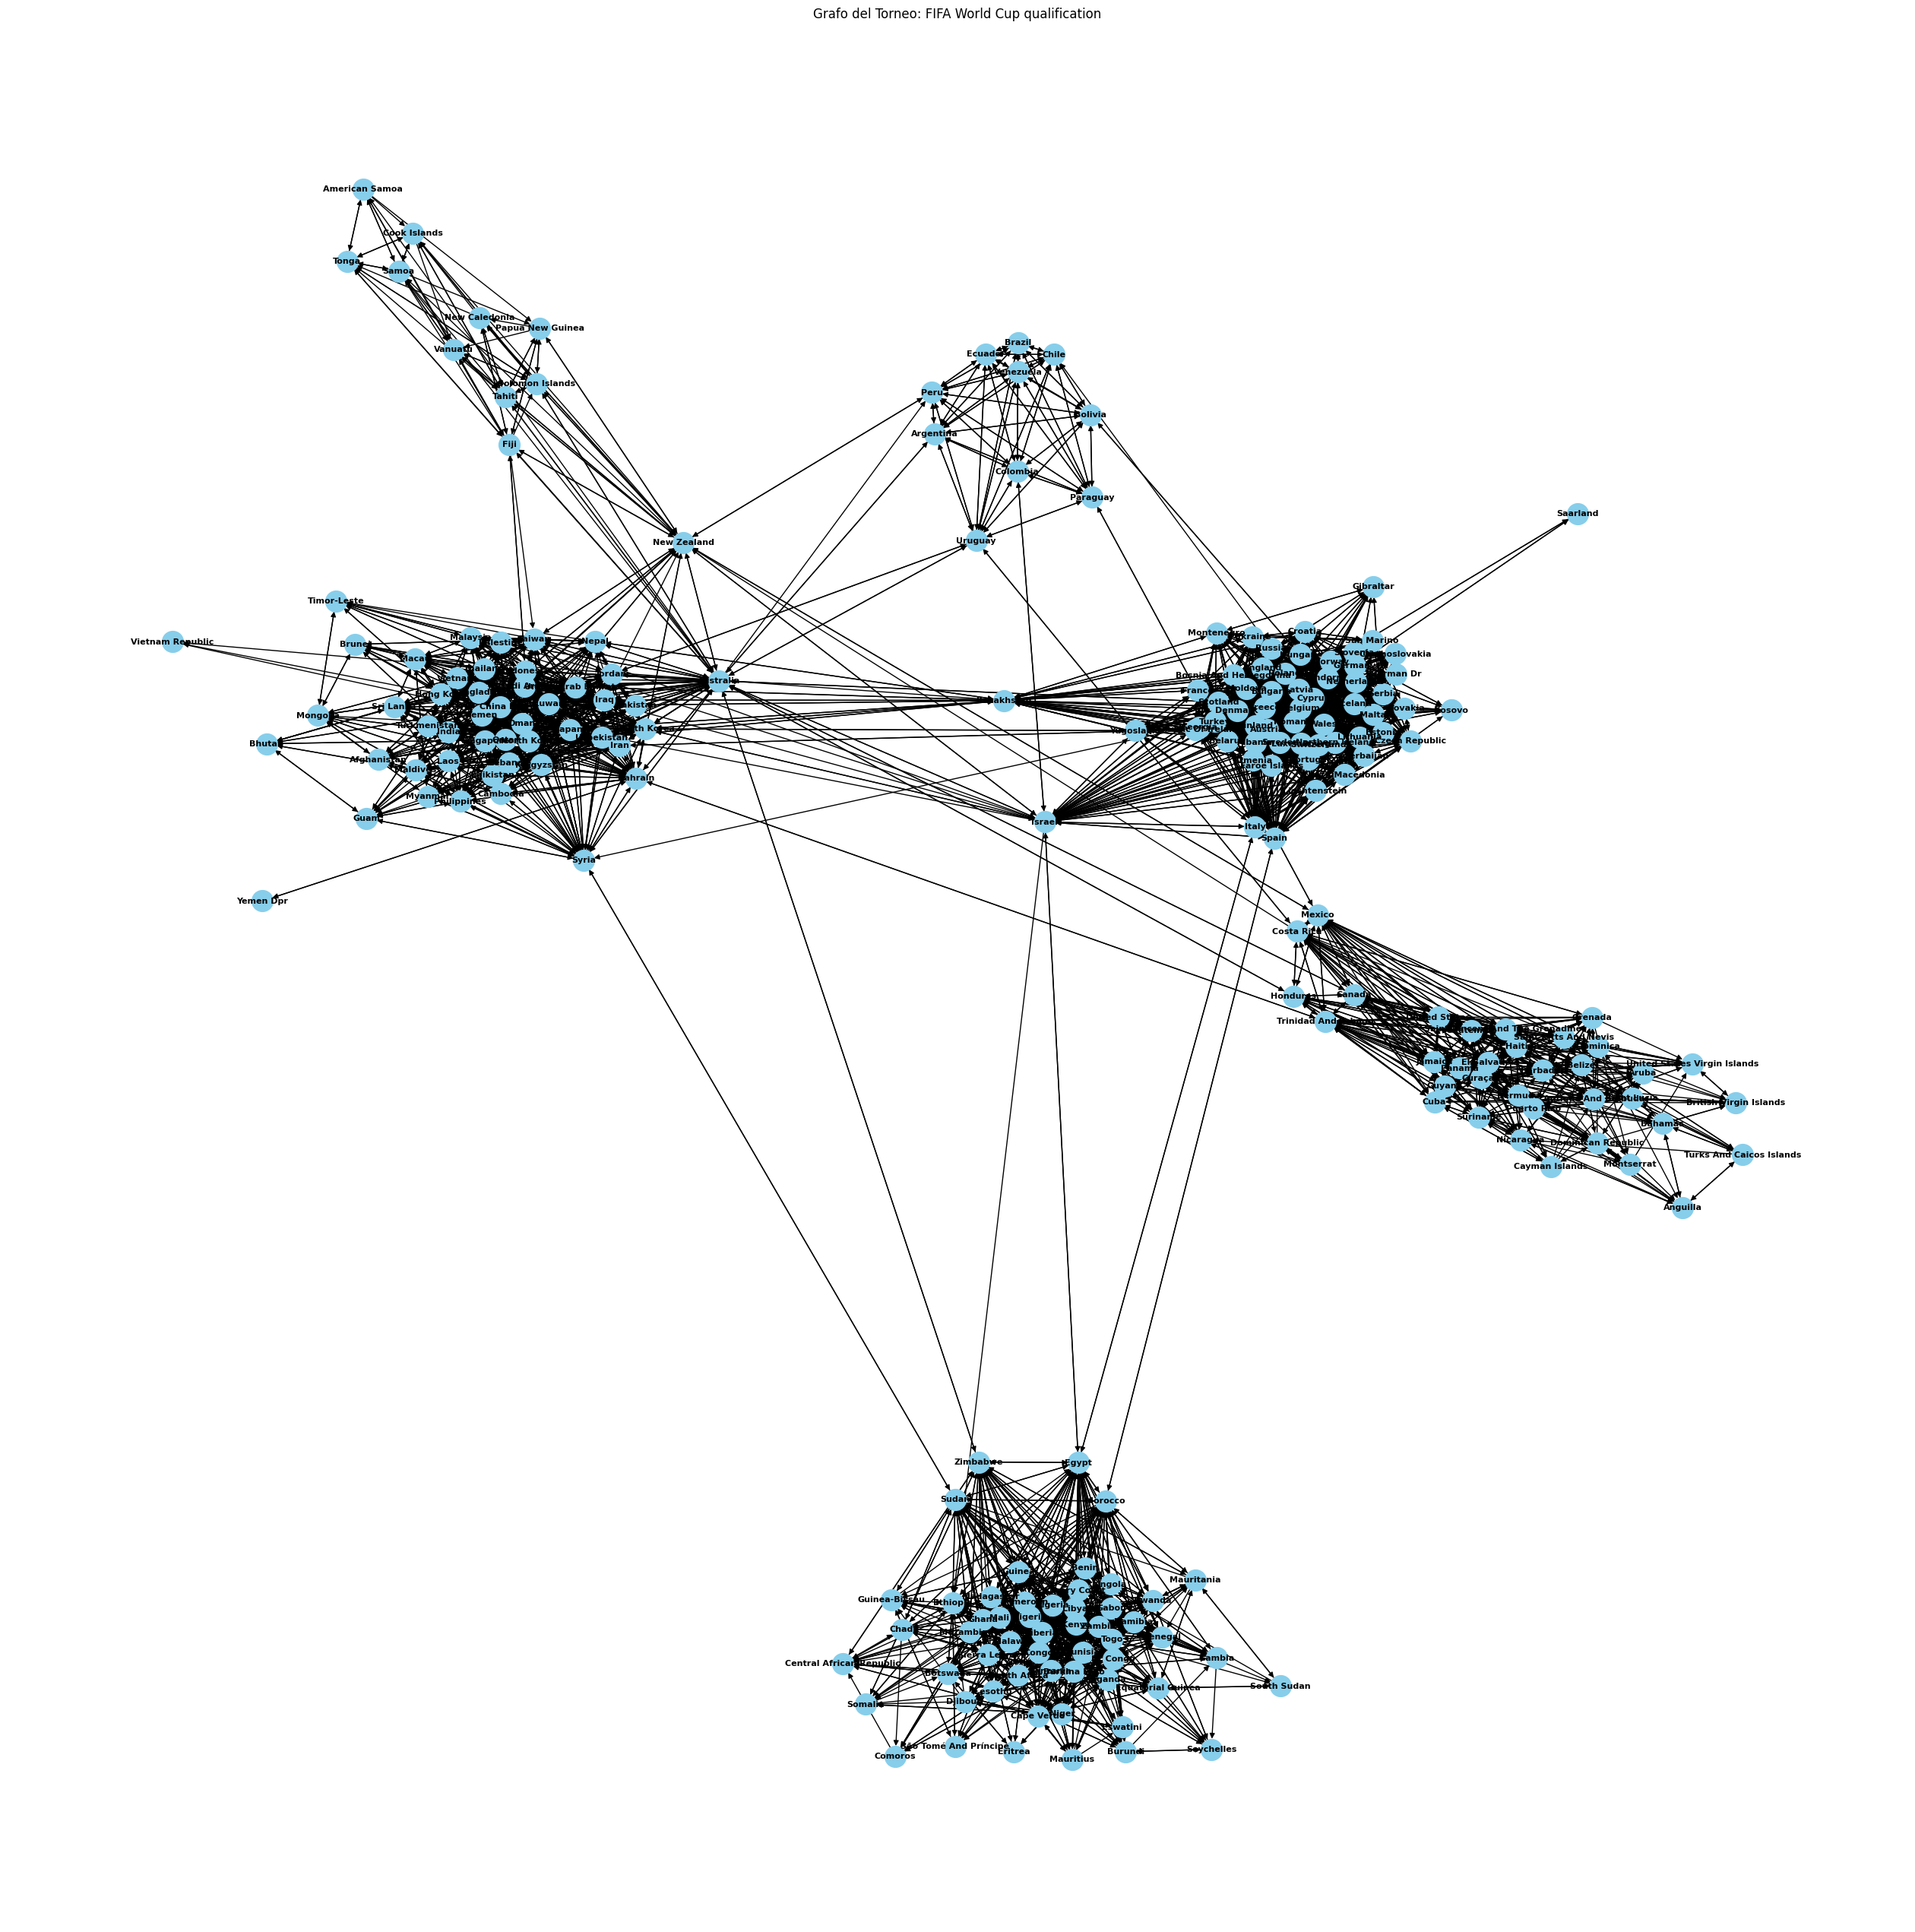

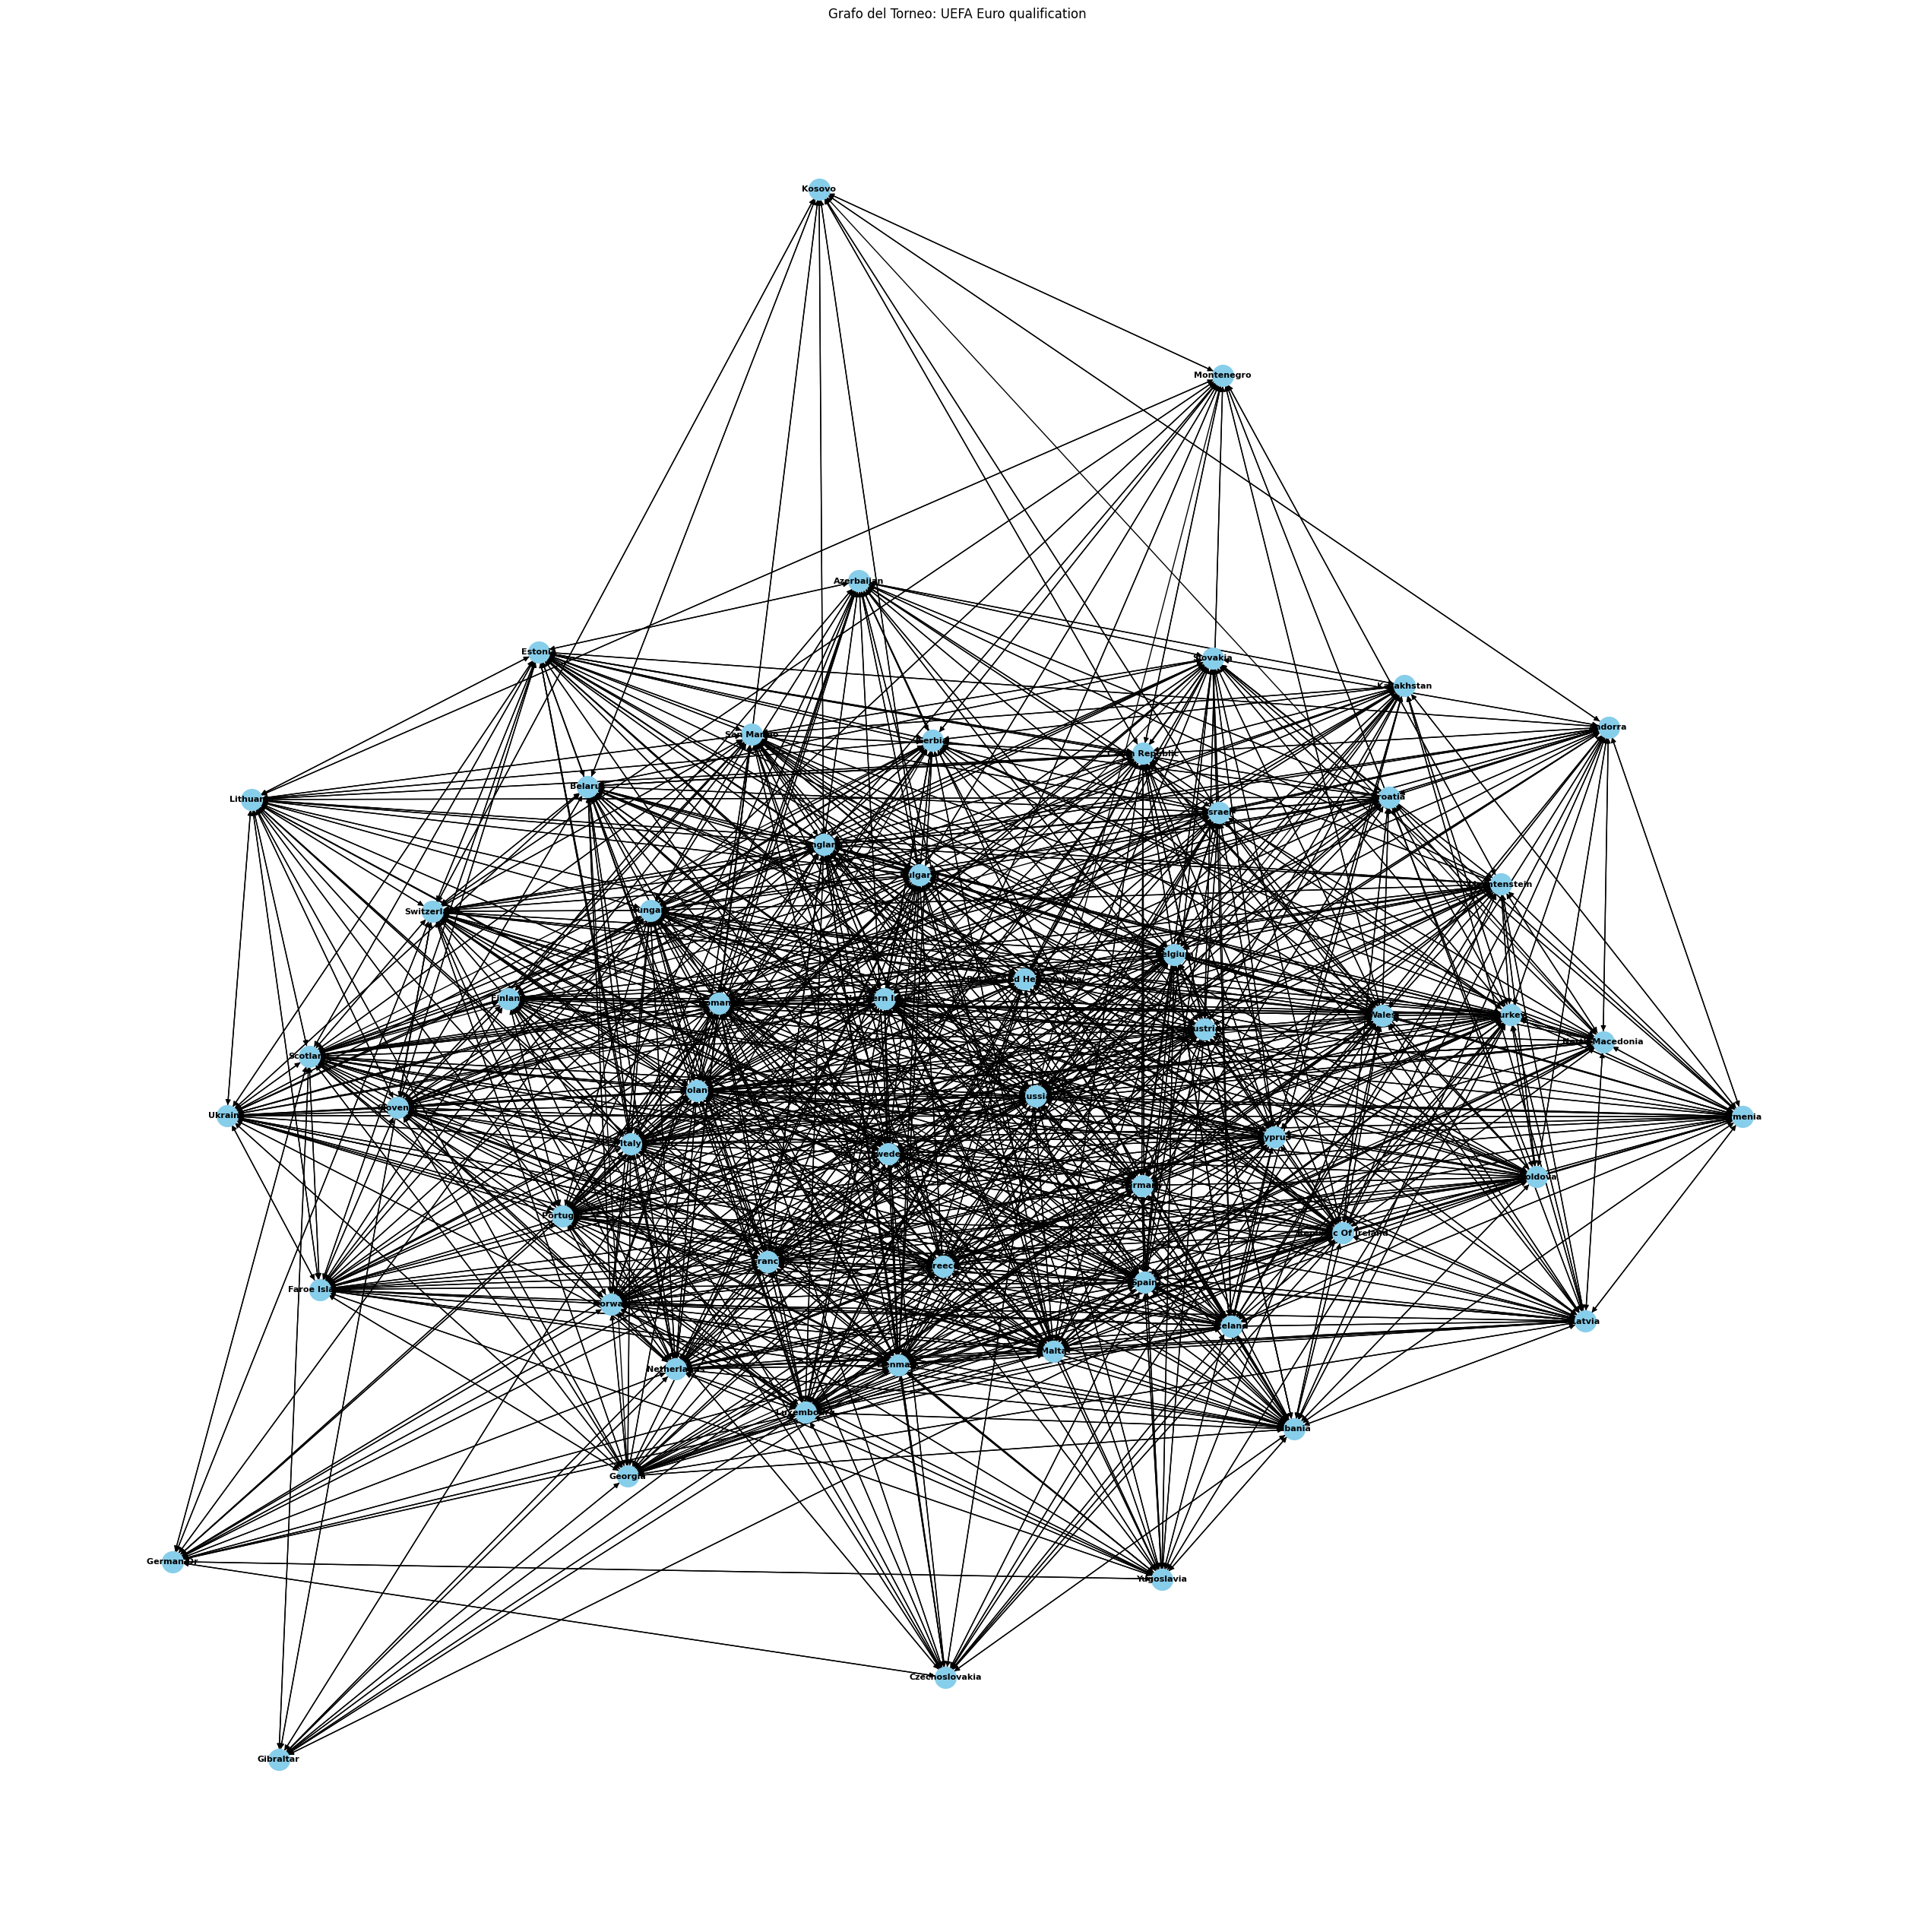

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# 1. Obtener los 3 torneos más famosos
top_3_tournaments = Results['tournament'].value_counts().head(3).index.tolist()

# 2. Crear un grafo para cada torneo
for tournament in top_3_tournaments:
    # Filtrar datos por torneo
    tournament_data = Results[Results['tournament'] == tournament]

    # Crear grafo
    graph = nx.DiGraph()  # Usamos un grafo  dirigido (Graph)

    # Añadir nodos (equipos)
    teams = set(tournament_data['home_team'].unique()) | set(tournament_data['away_team'].unique())
    graph.add_nodes_from(teams)

    # Añadir aristas (partidos)
    for _, row in tournament_data.iterrows():
        graph.add_edge(row['home_team'], row['away_team'])

    # 3. Visualizar el grafo
    plt.figure(figsize=(25, 25))  # Ajustar tamaño de la figura
    pos = nx.spring_layout(graph, seed=42)  # Posicionar nodos para mejor visualización
    nx.draw(graph, pos, with_labels=True, node_size=400, node_color="skyblue", font_size=8, font_weight='bold')
    plt.title(f"Grafo del Torneo: {tournament}")
    plt.show()

In [ ]:
#Metricas friendly

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'Results' is your DataFrame

# Filter data for the 'Friendly' tournament
tournament_data = Results[Results['tournament'] == 'Friendly']

# Create an undirected graph for the 'Friendly' tournament
graph = nx.Graph()
teams = set(tournament_data['home_team'].unique()) | set(tournament_data['away_team'].unique())
graph.add_nodes_from(teams)
for _, row in tournament_data.iterrows():
    graph.add_edge(row['home_team'], row['away_team'])

# Calculate and display metrics for the 'Friendly' tournament
degree_centrality = nx.degree_centrality(graph)
betweenness_centrality = nx.betweenness_centrality(graph)
eigenvector_centrality = nx.eigenvector_centrality(graph)
connected_components = list(nx.connected_components(graph))

print("\nMétricas para el torneo: Friendly")
print("Centralidad de grado:", degree_centrality)
print("Centralidad de intermediación:", betweenness_centrality)
print("Centralidad de vector propio:", eigenvector_centrality)
print("Componentes conectados:", connected_components)

# Identify key teams (e.g., using degree centrality)
key_teams = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:5]  # Top 5 teams
print("Equipos clave (por centralidad de grado):", key_teams)


Métricas para el torneo: Friendly
Centralidad de grado: {'Parishes Of Jersey': 0.0034602076124567475, 'Afghanistan': 0.06574394463667821, 'Cameroon': 0.2698961937716263, 'Nicaragua': 0.07612456747404844, 'Mozambique': 0.08996539792387544, 'Albania': 0.17993079584775087, 'Timor-Leste': 0.01730103806228374, 'Canada': 0.2768166089965398, 'Honduras': 0.15570934256055363, 'Taiwan': 0.08304498269896193, 'Syria': 0.13494809688581316, 'China Pr': 0.356401384083045, 'Faroe Islands': 0.07958477508650519, 'Algeria': 0.2768166089965398, 'Chile': 0.27335640138408307, 'Northern Ireland': 0.20069204152249134, 'Comoros': 0.058823529411764705, 'Somaliland': 0.006920415224913495, 'Indonesia': 0.23875432525951557, 'Croatia': 0.1972318339100346, 'Tunisia': 0.32525951557093424, 'North Macedonia': 0.16955017301038064, 'Czechoslovakia': 0.14186851211072665, 'Kosovo': 0.08304498269896193, 'Djibouti': 0.02422145328719723, 'Anguilla': 0.020761245674740483, 'Israel': 0.21453287197231835, 'Papua New Guinea': 0.0

In [ ]:
#Métricas WC


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'Results' is your DataFrame

# Filter data for the 'World Cup qualification' tournament
# Check for potential typos or name variations in your DataFrame
tournament_data = Results[Results['tournament'].str.contains('World Cup qualification', case=False)]

# Create an undirected graph for the 'World Cup qualification' tournament
# Only create the graph if there is data available
if not tournament_data.empty:
    graph = nx.Graph()
    teams = set(tournament_data['home_team'].unique()) | set(tournament_data['away_team'].unique())
    graph.add_nodes_from(teams)
    for _, row in tournament_data.iterrows():
        graph.add_edge(row['home_team'], row['away_team'])

    # Calculate and display metrics for the 'World Cup qualification' tournament
    degree_centrality = nx.degree_centrality(graph)
    betweenness_centrality = nx.betweenness_centrality(graph)
    eigenvector_centrality = nx.eigenvector_centrality(graph)
    connected_components = list(nx.connected_components(graph))

    print("\nMétricas para el torneo: World Cup qualification")
    print("Centralidad de grado:", degree_centrality)
    print("Centralidad de intermediación:", betweenness_centrality)
    print("Centralidad de vector propio:", eigenvector_centrality)
    print("Componentes conectados:", connected_components)

    # Identify key teams (e.g., using degree centrality)
    key_teams = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:5]  # Top 5 teams
    print("Equipos clave (por centralidad de grado):", key_teams)
else:
    print("No data found for 'World Cup qualification' tournament.")


Métricas para el torneo: World Cup qualification
Centralidad de grado: {'Afghanistan': 0.05555555555555555, 'Cameroon': 0.11574074074074073, 'Nicaragua': 0.06481481481481481, 'Mozambique': 0.09259259259259259, 'Albania': 0.17129629629629628, 'Timor-Leste': 0.037037037037037035, 'Canada': 0.10185185185185185, 'Honduras': 0.07870370370370369, 'Taiwan': 0.1111111111111111, 'Syria': 0.1388888888888889, 'China Pr': 0.16666666666666666, 'Faroe Islands': 0.13425925925925924, 'Algeria': 0.14814814814814814, 'Chile': 0.046296296296296294, 'Northern Ireland': 0.17592592592592593, 'Comoros': 0.032407407407407406, 'Indonesia': 0.1388888888888889, 'Croatia': 0.125, 'Tunisia': 0.1388888888888889, 'North Macedonia': 0.125, 'Czechoslovakia': 0.09259259259259259, 'Kosovo': 0.041666666666666664, 'Djibouti': 0.05555555555555555, 'Anguilla': 0.046296296296296294, 'Israel': 0.17592592592592593, 'Papua New Guinea': 0.037037037037037035, 'Montenegro': 0.08796296296296297, 'Turkmenistan': 0.08796296296296297

In [ ]:
#Métricas Euro

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'Results' is your DataFrame

# Filter data for the 'UEFA Euro qualification' tournament
tournament_data = Results[Results['tournament'] == 'UEFA Euro qualification']

# Create an undirected graph for the 'UEFA Euro qualification' tournament
graph = nx.Graph()
teams = set(tournament_data['home_team'].unique()) | set(tournament_data['away_team'].unique())
graph.add_nodes_from(teams)
for _, row in tournament_data.iterrows():
    graph.add_edge(row['home_team'], row['away_team'])

# Calculate and display metrics for the 'UEFA Euro qualification' tournament
degree_centrality = nx.degree_centrality(graph)
betweenness_centrality = nx.betweenness_centrality(graph)
eigenvector_centrality = nx.eigenvector_centrality(graph)
connected_components = list(nx.connected_components(graph))

print("\nMétricas para el torneo: UEFA Euro qualification")
print("Centralidad de grado:", degree_centrality)
print("Centralidad de intermediación:", betweenness_centrality)
print("Centralidad de vector propio:", eigenvector_centrality)
print("Componentes conectados:", connected_components)

# Identify key teams (e.g., using degree centrality)
key_teams = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:5]  # Top 5 teams
print("Equipos clave (por centralidad de grado):", key_teams)


Métricas para el torneo: UEFA Euro qualification
Centralidad de grado: {'San Marino': 0.5438596491228069, 'Lithuania': 0.42105263157894735, 'Albania': 0.5789473684210527, 'German Dr': 0.2631578947368421, 'Sweden': 0.5964912280701754, 'Estonia': 0.49122807017543857, 'Armenia': 0.47368421052631576, 'Spain': 0.6491228070175439, 'Austria': 0.6842105263157894, 'Belgium': 0.6140350877192982, 'France': 0.6842105263157894, 'Scotland': 0.631578947368421, 'Czech Republic': 0.5263157894736842, 'Wales': 0.6491228070175439, 'Faroe Islands': 0.5263157894736842, 'Gibraltar': 0.17543859649122806, 'Switzerland': 0.5789473684210527, 'Yugoslavia': 0.38596491228070173, 'Russia': 0.7017543859649122, 'Northern Ireland': 0.6491228070175439, 'Slovenia': 0.5438596491228069, 'Finland': 0.5087719298245614, 'Croatia': 0.43859649122807015, 'North Macedonia': 0.47368421052631576, 'Czechoslovakia': 0.3157894736842105, 'Kosovo': 0.17543859649122806, 'Hungary': 0.631578947368421, 'Moldova': 0.47368421052631576, 'Gree

### Grafo Asian Cup

In [ ]:
asian_cup_results = Results[Results['tournament'] == 'AFC Asian Cup']

In [ ]:
import networkx as nx

# Crear un grafo dirigido
asian_cup_graph = nx.DiGraph()

# Agregar nodos (equipos)
for team in asian_cup_results['home_team'].unique():  # Puedes usar home_team o away_team
    asian_cup_graph.add_node(team)

# Agregar aristas (partidos) con la dirección de la victoria
for index, row in asian_cup_results.iterrows():
    if row['home_score'] > row['away_score']:
        asian_cup_graph.add_edge(row['home_team'], row['away_team'])
    elif row['home_score'] < row['away_score']:
        asian_cup_graph.add_edge(row['away_team'], row['home_team'])
    # else:  # Manejo de empates (opcional)

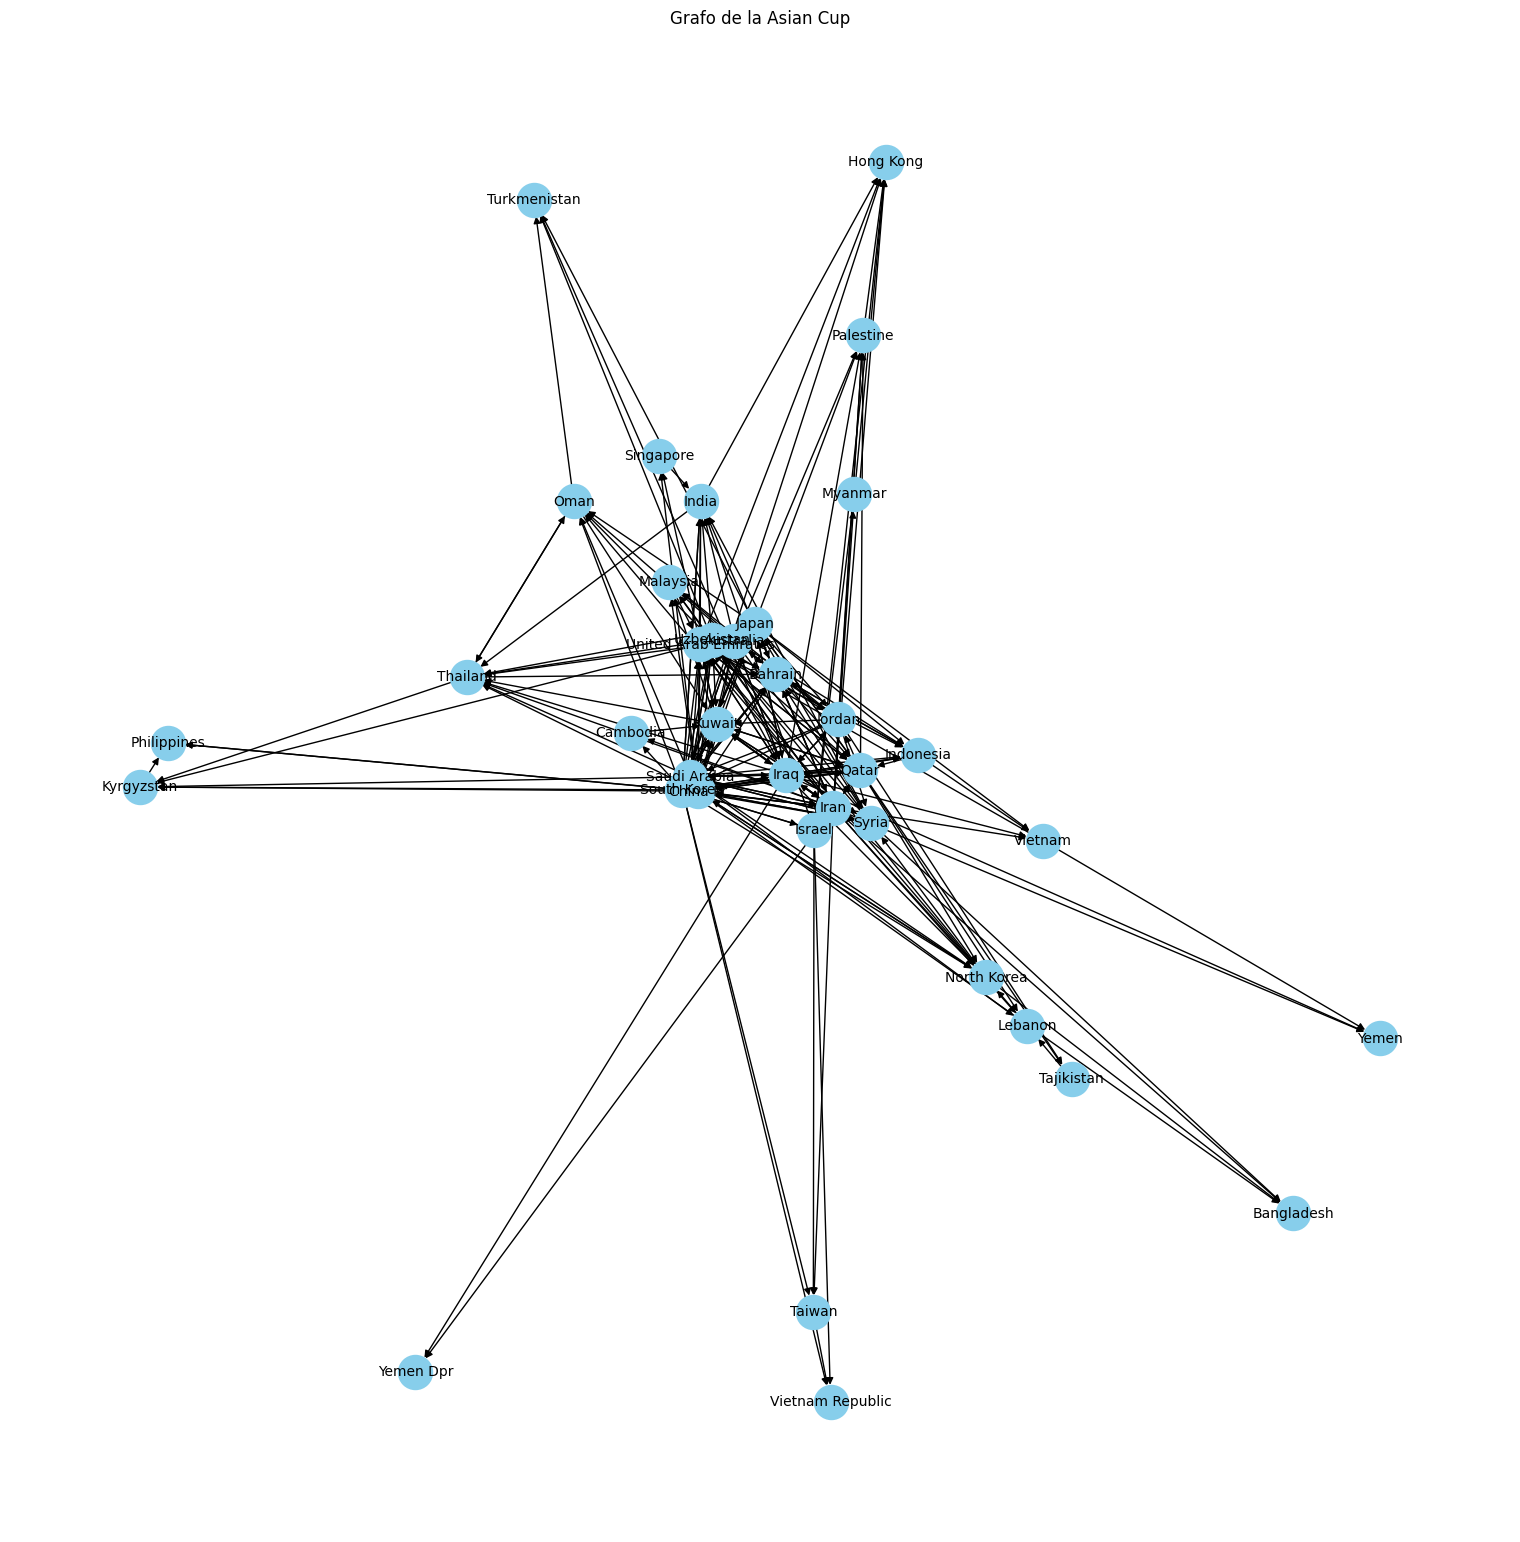

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 15))

nx.draw(asian_cup_graph, with_labels=True, node_size=600,font_size=10, node_color="skyblue")
plt.title("Grafo de la Asian Cup")
plt.show()

In [ ]:
import networkx as nx


asian_cup_data = Results[Results['tournament'] == 'AFC Asian Cup']


# Construir el grafo
G = nx.Graph()
for index, row in asian_cup_data.iterrows():
    G.add_edge(row['home_team'], row['away_team'], weight=1)  # Peso = 1 para cada partido

# Calcular el grado de cada nodo
degree_centrality = nx.degree_centrality(G)

# Calcular la centralidad de intermediación de cada nodo
betweenness_centrality = nx.betweenness_centrality(G)

# Calcular el coeficiente de agrupamiento del grafo
clustering_coefficient = nx.average_clustering(G)

# Calcular la densidad del grafo
density = nx.density(G)

# Imprimir las métricas
print("Grado de cada nodo:")
print(degree_centrality.values())
print("Centralidad de intermediación de cada nodo:")
print(betweenness_centrality)
print("Coeficiente de agrupamiento del grafo:")
print(clustering_coefficient)
print("Densidad del grafo:")
print(density)

Grado de cada nodo:
dict_values([0.25, 0.19444444444444442, 0.7222222222222222, 0.1111111111111111, 0.16666666666666666, 0.3333333333333333, 0.7777777777777777, 0.1111111111111111, 0.1111111111111111, 0.5833333333333333, 0.4722222222222222, 0.5, 0.25, 0.6388888888888888, 0.05555555555555555, 0.611111111111111, 0.3333333333333333, 0.1111111111111111, 0.41666666666666663, 0.5555555555555556, 0.5277777777777778, 0.1111111111111111, 0.4444444444444444, 0.5555555555555556, 0.3055555555555555, 0.5, 0.2222222222222222, 0.1388888888888889, 0.41666666666666663, 0.3055555555555555, 0.41666666666666663, 0.2222222222222222, 0.25, 0.19444444444444442, 0.08333333333333333, 0.08333333333333333, 0.1388888888888889])
Centralidad de intermediación de cada nodo:
{'Hong Kong': 0.014030932238215147, 'Israel': 0.0050964291440481905, 'South Korea': 0.13926964990524626, 'Vietnam Republic': 0.0, 'Taiwan': 0.0034033074509264988, 'India': 0.012312548562548561, 'Iran': 0.20988473574792313, 'Myanmar': 0.0, 'Cambod


Métricas para el torneo: UEFA European Championship
Centralidad de grado: {}
Centralidad de intermediación: {}
Componentes conectados: []
Equipos clave (por centralidad de grado): []


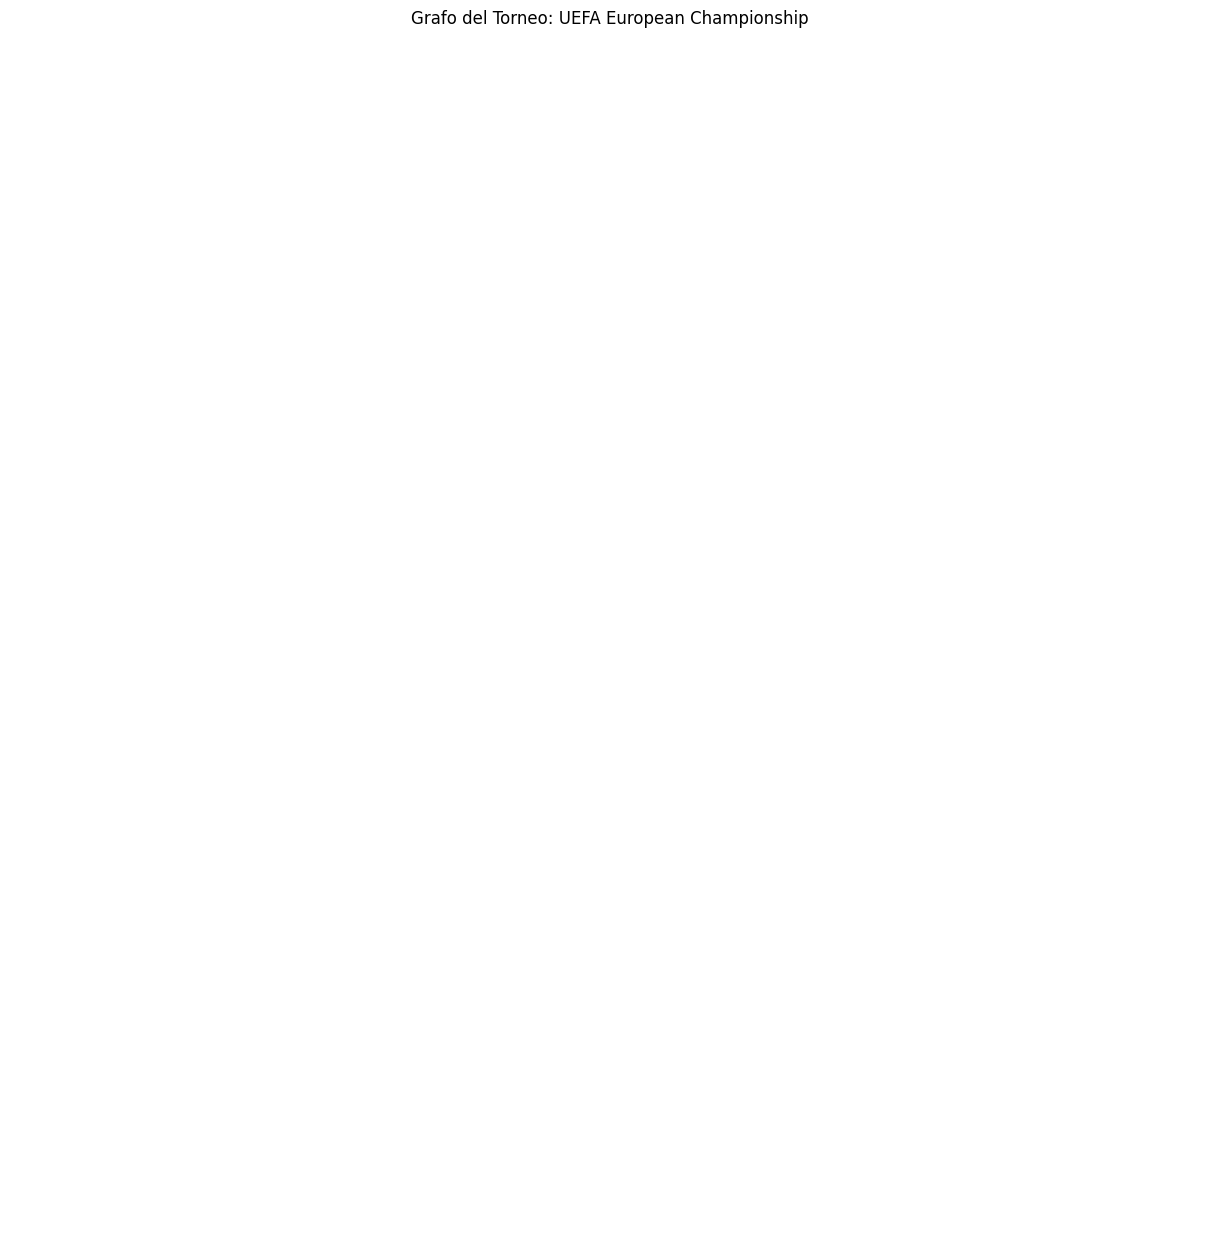


Métricas para el torneo: AFC Asian Cup
Centralidad de grado: {'Oman': 0.3055555555555555, 'Turkmenistan': 0.1388888888888889, 'Iraq': 0.5833333333333333, 'Bangladesh': 0.1111111111111111, 'Singapore': 0.1111111111111111, 'Iran': 0.7777777777777777, 'Kuwait': 0.5, 'Cambodia': 0.1111111111111111, 'United Arab Emirates': 0.611111111111111, 'South Korea': 0.7222222222222222, 'Myanmar': 0.1111111111111111, 'Philippines': 0.08333333333333333, 'Hong Kong': 0.25, 'Taiwan': 0.16666666666666666, 'Australia': 0.41666666666666663, 'Yemen Dpr': 0.05555555555555555, 'Syria': 0.41666666666666663, 'Saudi Arabia': 0.5277777777777778, 'China Pr': 0.6388888888888888, 'Bahrain': 0.4444444444444444, 'Qatar': 0.5555555555555556, 'Kyrgyzstan': 0.19444444444444442, 'Thailand': 0.4722222222222222, 'Japan': 0.5555555555555556, 'Jordan': 0.41666666666666663, 'Yemen': 0.08333333333333333, 'Malaysia': 0.25, 'Tajikistan': 0.1388888888888889, 'Indonesia': 0.3055555555555555, 'Vietnam Republic': 0.1111111111111111, 

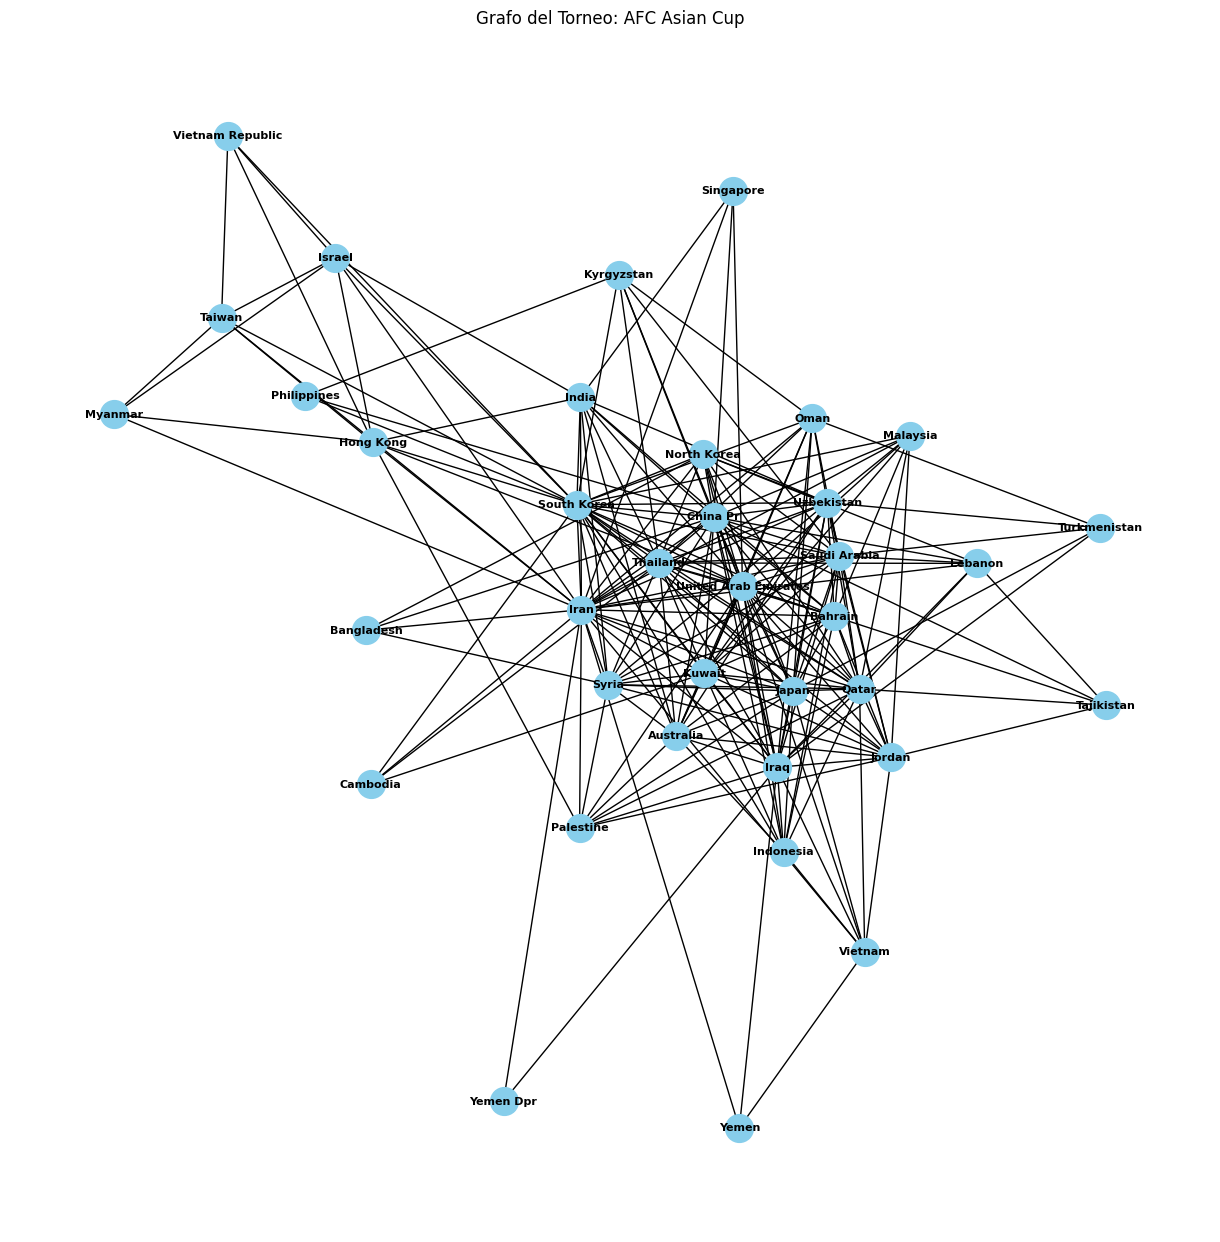

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# Asumiendo que 'Results' es tu DataFrame

tournaments = ['UEFA European Championship', 'AFC Asian Cup']

for tournament in tournaments:
    # Filtrar datos para el torneo actual
    tournament_data = Results[Results['tournament'] == tournament]

    # Crear un grafo no dirigido para el torneo actual
    graph = nx.Graph()
    teams = set(tournament_data['home_team'].unique()) | set(tournament_data['away_team'].unique())
    graph.add_nodes_from(teams)
    for _, row in tournament_data.iterrows():
        graph.add_edge(row['home_team'], row['away_team'])

    # Calcular métricas
    degree_centrality = nx.degree_centrality(graph)
    betweenness_centrality = nx.betweenness_centrality(graph)

    connected_components = list(nx.connected_components(graph))

    # Mostrar métricas
    print(f"\nMétricas para el torneo: {tournament}")
    print("Centralidad de grado:", degree_centrality)
    print("Centralidad de intermediación:", betweenness_centrality)

    print("Componentes conectados:", connected_components)

    # Identificar equipos clave (por ejemplo, usando centralidad de grado)
    key_teams = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:5]  # Top 5 equipos
    print("Equipos clave (por centralidad de grado):", key_teams)

    # Visualizar el grafo
    plt.figure(figsize=(12, 12))  # Ajustar tamaño de la figura
    pos = nx.spring_layout(graph, seed=42)  # Posicionar nodos para mejor visualización
    nx.draw(graph, pos, with_labels=True, node_size=400, node_color="skyblue", font_size=8, font_weight='bold')
    plt.title(f"Grafo del Torneo: {tournament}")
    plt.show()

### Visualiza el Grafo y discute tus hallazgos en máximo de 2 Páginas.

## **Informe Final (2 puntos)**

### Integra todos tus análisis en un informe final que contenga:



*  Exploración inicial y limpieza de datos.
* Análisis descriptivo.
* Resultados de análisis bayesiano.
* Modelos predictivos.
* Resultados avanzados de grafos.



### Máximo 13 Páginas en pdf